# Bibliotecas

In [1]:
# Manipulación de datos
import pandas as pd
import numpy as np
import re

In [2]:
# Graficas
import matplotlib.pyplot as plt
from matplotlib import cycler
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [3]:
# Escalamiento
from sklearn.preprocessing import StandardScaler

# Componentes principales
from sklearn.decomposition import PCA

# Modelo de clustering
from sklearn.cluster import KMeans

# Métricas para selección de clusters
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score

# Pruebas estadísticas
from scipy.stats import kruskal

In [4]:
# !pip install nltk

from scipy import stats
from collections import Counter
import nltk # para trabajar con tokenizacion y stopwords (ejercicio 2)

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Ejercicio 1

## Cargar datos

In [6]:
songs1 = pd.read_csv(r'https://raw.githubusercontent.com/Wsm-erick/Diplomado/refs/heads/main/Modulo-I/Datasets/features_songs.csv')

In [7]:
songs1.shape

(175, 40)

In [8]:
songs1.head()

,archivo,duration,rms,tempo,zcr,spectral_centroid,spectral_bandwidth,spectral_rolloff,spectral_contrast,mfcc_1,...,chroma_9,chroma_10,chroma_11,chroma_12,tonnetz_1,tonnetz_2,tonnetz_3,tonnetz_4,tonnetz_5,tonnetz_6
0,02 Maroon.mp3,218.305306,0.269286,[107.66601562],0.030423,2131.429071,3054.294473,4833.956751,21.985519,-165.31206,...,0.601635,0.531422,0.506995,0.518395,0.275898,0.210128,0.175254,0.011638,0.049738,-0.057944
1,03 Anti-Hero.mp3,200.724898,0.251603,[97.50884434],0.042470,2270.523020,2887.932364,4680.853820,20.961313,-116.05038,...,0.481668,0.461698,0.506635,0.596817,0.067301,-0.201125,-0.039244,0.056137,0.023695,-0.028362
2,04 Snow On The Beach.mp3,256.156735,0.191276,[109.95678191],0.026679,1691.923217,2516.562246,3338.831279,21.885129,-205.33786,...,0.507185,0.615904,0.499524,0.530878,0.140940,-0.188128,-0.098086,-0.042389,0.013691,-0.021691
3,"05 You_re On Your Own, Kid.mp3",194.246531,0.261242,[120.18531977],0.021683,1637.701889,2600.810313,3373.619237,21.883741,-183.35786,...,0.440590,0.486334,0.450555,0.462748,0.128289,0.005553,0.065578,-0.140425,0.006879,0.009277
4,06 Midnight Rain.mp3,174.837551,0.226225,[69.83741554],0.021928,1485.590595,2261.139587,3117.497364,21.791955,-223.94078,...,0.479455,0.510774,0.485107,0.532159,0.107616,0.223978,-0.027103,0.086051,0.020835,0.057351


## Descripción de las variables

![variables](songs_var_description.png)

## Actividad

![actividad](songs_activity.png)

## Exploración

### Tipo de dato por variable

In [9]:
songs1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175 entries, 0 to 174
Data columns (total 40 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   archivo             175 non-null    object 
 1   duration            175 non-null    float64
 2   rms                 175 non-null    float64
 3   tempo               175 non-null    object 
 4   zcr                 175 non-null    float64
 5   spectral_centroid   175 non-null    float64
 6   spectral_bandwidth  175 non-null    float64
 7   spectral_rolloff    175 non-null    float64
 8   spectral_contrast   175 non-null    float64
 9   mfcc_1              175 non-null    float64
 10  mfcc_2              175 non-null    float64
 11  mfcc_3              175 non-null    float64
 12  mfcc_4              175 non-null    float64
 13  mfcc_5              175 non-null    float64
 14  mfcc_6              175 non-null    float64
 15  mfcc_7              175 non-null    float64
 16  mfcc_8  

### Valores ausentes

In [10]:
def is_na_df(df):
    #Establecemos el resumen de NAs por columna
    na_summary = (
        df.isna().sum()
        .reset_index()
        .rename(columns={"index": "columna", 0: "n_missing"})
    )

    #Tomamos totales y prporciones
    na_summary["total"] = len(df)
    na_summary["prop_missing"] = na_summary["n_missing"] / na_summary["total"]
    na_summary["prop_original"] = 1 - na_summary["prop_missing"]

    #Filtramos solo columnas con al menos 1 NA
    na_summary = na_summary[na_summary["n_missing"] > 0].reset_index(drop=True)

    #Agregamos fila resumen global
    total_missing = df.isna().sum().sum()
    total_elements = df.size
    prop_missing_global = total_missing / total_elements
    prop_original_global = 1 - prop_missing_global

    resumen = pd.DataFrame({
        "columna": ["TOTAL"],
        "n_missing": [total_missing],
        "total": [total_elements],
        "prop_missing": [prop_missing_global],
        "prop_original": [prop_original_global]
    })

    #Creamos la tabla
    na_summary = pd.concat([na_summary, resumen], ignore_index=True)

    return na_summary

In [11]:
is_na_df(songs1)

,columna,n_missing,total,prop_missing,prop_original
0,TOTAL,0,7000,0.0,1.0


No hay valores ausentes por lo que no hace falta aplicar un método de imputación.

### Distribución de variables numéricas

In [12]:
var_cat = songs1.select_dtypes(['object']).columns.tolist()
var_cat

['archivo', 'tempo']

In [13]:
songs1['tempo_num'] = songs1['tempo'].str[1:-1].astype(float)

In [14]:
def guess_lang_heuristic(text: str):

    spanish_words = {
        "el","la","los","las","un","una","unos","unas","de","del","al","y","o","u",
        "que","como","con","por","para","sin","sobre","entre","más","menos","mi","tu",
        "te","se","me","lo","le","su","si","ya","no","sí","a","en"
    }

    tokens = {t for t in re.findall(r"\b\w+\b", text)}
    hits = len(tokens & spanish_words)
    
    # si tiene acentos/símbolos muy comunes en español, suma
    accent_bonus = 1 if re.search(r"[áéíóúñü]", text.lower()) else 0
    score_es = hits + accent_bonus
    
    # título muy corto => baja confianza
    conf = min(1.0, 0.2*score_es + 0.2*(len(tokens) >= 3))
    if score_es >= 2:
        return "es", conf

    # si no hay indicios en español y tiene muchas palabras comunes en inglés
    english_words = {"the","and","you","your","i","me","my","on","in","with","for","of","to","from","at","it","is"}
    hits_en = len(tokens & english_words)
    if hits_en >= 2:
        return "en", max(conf, 0.6)
        
    # por defecto “en” si todo está en ASCII y sin acentos; si no, desconocido
    return ("en", 0.5) if text.isascii() else ("unk", 0.3)

In [15]:
def label_from_code(code):
    return {"es":"Español","en":"Inglés","unk":"Desconocido"}.get(code,"Desconocido")

In [16]:
songs1['archivo'] = songs1['archivo'].str.replace('.mp3' , '').str.lower()

In [17]:
songs1['archivo'].to_csv('canciones.csv')

In [18]:
songs1["lang_code"], songs1["lang_conf"] = zip(*songs1["archivo"].map(guess_lang_heuristic))
songs1["lang"] = songs1["lang_code"].map(label_from_code)

In [19]:
songs1.head(3)

,archivo,duration,rms,tempo,zcr,spectral_centroid,spectral_bandwidth,spectral_rolloff,spectral_contrast,mfcc_1,...,tonnetz_1,tonnetz_2,tonnetz_3,tonnetz_4,tonnetz_5,tonnetz_6,tempo_num,lang_code,lang_conf,lang
0,02 maroon,218.305306,0.269286,[107.66601562],0.030423,2131.429071,3054.294473,4833.956751,21.985519,-165.31206,...,0.275898,0.210128,0.175254,0.011638,0.049738,-0.057944,107.666016,en,0.5,Inglés
1,03 anti-hero,200.724898,0.251603,[97.50884434],0.042470,2270.523020,2887.932364,4680.853820,20.961313,-116.05038,...,0.067301,-0.201125,-0.039244,0.056137,0.023695,-0.028362,97.508844,en,0.5,Inglés
2,04 snow on the beach,256.156735,0.191276,[109.95678191],0.026679,1691.923217,2516.562246,3338.831279,21.885129,-205.33786,...,0.140940,-0.188128,-0.098086,-0.042389,0.013691,-0.021691,109.956782,en,0.6,Inglés


In [20]:
class analyze:
    # Inicializamos la clase
    def __init__(self, df, num_vars, cat_vars):
        self.df = df
        self.num_vars = num_vars
        self.cat_vars = cat_vars

    #Método para graficar variables numéricas (cada una en figura independiente)
    def plot_num(self):
        for var in self.num_vars:
            fig = make_subplots(rows=1, cols=2, subplot_titles=(f"{var} - Boxplot", f"{var} - Histograma"))

            # Boxplot
            fig.add_trace(
                go.Box(y=self.df[var], name="Boxplot", marker_color="#008080"),
                row=1, col=1
            )

            # Histograma
            fig.add_trace(
                go.Histogram(x=self.df[var], name="Histograma",
                             #marker_color="#00a77d", 
                             #marker_color='#722F37',
                             marker_color="rgba(114, 47, 55, 0.5)",  # burdeos con 50% transparencia
                             nbinsx=50,
                             histnorm='probability density'),
                row=1, col=2
            )

            fig.update_layout(title_text=f"Variable numérica: {var}", height=400, width=800)
            fig.show()

    #Método para graficar variables categóricas
    def plot_cat(self):
        n = len(self.cat_vars)
        cols = 2
        rows = (n + 1) // cols if n > 1 else 1

        fig = make_subplots(
            rows=rows, cols=cols,
            specs=[[{'type':'domain'}]*cols for _ in range(rows)],
            subplot_titles=self.cat_vars
        )

        for i, var in enumerate(self.cat_vars):
            row = i // cols + 1
            col = i % cols + 1

            value_counts = self.df[var].value_counts()
            labels = value_counts.index.astype(str)
            values = value_counts.values

            wine_palette = [
                "#722F37", "#B85042", "#E6AF2E", "#F6D55C", "#F4A7B9",
                "#2F4F4F", "#8D6E63", "#A1887F", "#D7CCC8", "#795548"
            ]
            
            fig.add_trace(
                go.Pie(
                    labels=labels, 
                    values=values, 
                    name=var, 
                    textinfo='percent+label',
                    marker=dict(colors=wine_palette)
                ),
                row=row, col=col
            )

            #fig.add_trace(
            #    go.Pie(labels=labels, values=values, name=var, textinfo='percent+label'),
            #    row=row, col=col
            #)

        fig.update_layout(title_text="Variables Categóricas", height=400*rows)
        fig.show()

    #Método para graficar la matriz de correlación de numéricas
    def corr_matrix(self, color: str, values: bool = True):
        corr_matrix = self.df[self.num_vars].corr()

        if values:
            fig = go.Figure(data=go.Heatmap(
                z=corr_matrix.values,
                x=corr_matrix.columns,
                y=corr_matrix.columns,
                colorscale=color,
                text=corr_matrix.round(1).values,      # valores de correlación con 1 decimal
                texttemplate="%{text}",                # mostrar texto en cada celda
                textfont={"size":10, "color":"black"}  # estilo de fuente
                ))
        else:
            fig = go.Figure(data=go.Heatmap(
                z=corr_matrix.values,
                x=corr_matrix.columns,
                y=corr_matrix.columns,
                colorscale=color
                ))

        fig.update_layout(
            title='Matriz de Correlación',
            width=800,
            height=600
        )

        fig.show()

In [21]:
var_cat = songs1.select_dtypes('object').columns.tolist()
var_num = list(set(songs1.columns)-set(var_cat))
var_cat

['archivo', 'tempo', 'lang_code', 'lang']

In [22]:
analisis = analyze(songs1, var_num, ['lang'])

In [23]:
songs1.describe()

,duration,rms,zcr,spectral_centroid,spectral_bandwidth,spectral_rolloff,spectral_contrast,mfcc_1,mfcc_2,mfcc_3,...,chroma_11,chroma_12,tonnetz_1,tonnetz_2,tonnetz_3,tonnetz_4,tonnetz_5,tonnetz_6,tempo_num,lang_conf
count,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,...,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000
mean,242.625580,0.178263,0.058199,2648.488772,2988.567941,5473.065749,21.801889,-158.931074,140.614699,-26.212339,...,0.456177,0.466682,0.040485,0.032733,0.013377,0.013172,0.002823,-0.002182,111.935760,0.535429
std,67.956199,0.049730,0.018800,635.439223,500.307972,1397.766313,0.858255,38.227926,21.623594,21.760878,...,0.085315,0.070548,0.103817,0.102631,0.069900,0.077798,0.019156,0.021415,22.777153,0.116962
min,124.240000,0.055421,0.018877,1036.709252,1320.658488,1975.675843,19.465870,-276.422400,85.240814,-75.233640,...,0.237338,0.254564,-0.222699,-0.293091,-0.228473,-0.211357,-0.046127,-0.063731,69.837416,0.300000
25%,191.916952,0.138568,0.044932,2252.657618,2654.740590,4612.901963,21.283166,-181.099535,125.182952,-42.279401,...,0.405111,0.425203,-0.032431,-0.028935,-0.037906,-0.042667,-0.009250,-0.014530,97.508844,0.500000
50%,229.111293,0.178693,0.057285,2645.661730,2989.998973,5520.686528,21.773645,-154.530210,139.702700,-26.979185,...,0.461059,0.466638,0.036603,0.038114,0.008709,0.019528,0.004239,-0.002709,107.666016,0.500000
75%,280.912120,0.209344,0.071291,3040.246637,3308.289221,6251.972851,22.263098,-133.741050,155.288480,-15.626485,...,0.508748,0.517050,0.122870,0.099992,0.053448,0.068193,0.012924,0.011443,120.185320,0.600000
max,472.201020,0.307894,0.106914,4261.901169,4387.397055,9319.848099,24.342274,-84.056380,220.203380,36.474575,...,0.642065,0.682561,0.290125,0.262957,0.175254,0.220034,0.049738,0.063773,198.768029,1.000000


In [24]:
analisis.plot_num()

In [25]:
analisis.plot_cat()

In [26]:
songs1.query("lang == 'Desconocido'").shape

(13, 44)

Eliminación de canciones de otro idioma distinto al inglés y al español

In [27]:
songs1.drop(songs1.query("lang == 'Desconocido'").index, inplace=True)

In [28]:
songs1.shape

(162, 44)

## Tratamiento de Datos

### Escalado

In [29]:
colors = ['aggrnyl', 'agsunset', 'algae', 'amp', 'armyrose', 'balance',
             'blackbody', 'bluered', 'blues', 'blugrn', 'bluyl', 'brbg',
             'brwnyl', 'bugn', 'bupu', 'burg', 'burgyl', 'cividis', 'curl',
             'darkmint', 'deep', 'delta', 'dense', 'earth', 'edge', 'electric',
             'emrld', 'fall', 'geyser', 'gnbu', 'gray', 'greens', 'greys',
             'haline', 'hot', 'hsv', 'ice', 'icefire', 'inferno', 'jet',
             'magenta', 'magma', 'matter', 'mint', 'mrybm', 'mygbm', 'oranges',
             'orrd', 'oryel', 'oxy', 'peach', 'phase', 'picnic', 'pinkyl',
             'piyg', 'plasma', 'plotly3', 'portland', 'prgn', 'pubu', 'pubugn',
             'puor', 'purd', 'purp', 'purples', 'purpor', 'rainbow', 'rdbu',
             'rdgy', 'rdpu', 'rdylbu', 'rdylgn', 'redor', 'reds', 'solar',
             'spectral', 'speed', 'sunset', 'sunsetdark', 'teal', 'tealgrn',
             'tealrose', 'tempo', 'temps', 'thermal', 'tropic', 'turbid',
             'turbo', 'twilight', 'viridis', 'ylgn', 'ylgnbu', 'ylorbr',
             'ylorrd']

In [30]:
analisis.corr_matrix('cividis', False)

In [31]:
X = songs1.drop(columns=var_cat + ['lang_conf'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Componentes Principales

In [32]:
class rPCA:
    #Inicializamos
    def __init__(self, dataframe, cols, n_comp):
        self.dataframe = dataframe
        self.cols = cols
        self.n_comp = n_comp

        if self.cols == None:
            self.dataframe = dataframe
        else:
            self.dataframe = dataframe[cols]

    #Ajustamos el PCA
    def r_pca(self):
        pca = PCA(n_components = self.n_comp)
        pca.fit(self.dataframe)
        self.df_trans = pd.DataFrame(pca.transform(self.dataframe), columns=[f'p_{i}' for i in range(len(pca.explained_variance_ratio_))])
        return self.df_trans, pca.explained_variance_ratio_.cumsum()

    #Diagrama del codo
    def plot_elbow(self):
        pca_temp = PCA().fit(self.dataframe)
        var_exp = pca_temp.explained_variance_ratio_
        cum_var_exp = var_exp.cumsum()

        plt.figure(figsize=(8, 5))
        plt.plot(range(1, len(var_exp) + 1), cum_var_exp, marker='o', linestyle='--', color='maroon')
        plt.xlabel('Número de Componentes')
        plt.ylabel('Varianza Acumulada Explicada')
        plt.title('Diagrama de Codo')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

In [33]:
var_num = [x for x in var_num if x != 'lang_conf']

In [34]:
pca_01 = rPCA(pd.DataFrame(X_scaled, columns=var_num), var_num, 0.90)

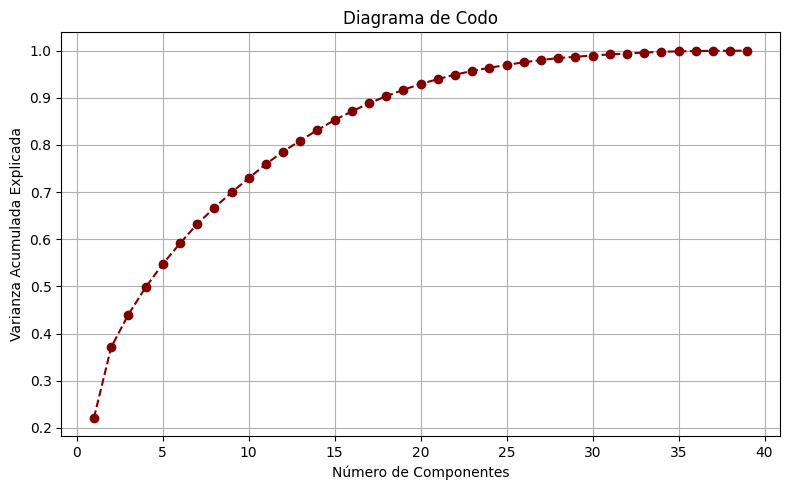

In [35]:
pca_01.plot_elbow()

In [36]:
print("Componentes:", pca_01.r_pca()[0].shape[1])

Componentes: 18


### Vecinos Cercanos

In [37]:
class rKMeans:
    #Inicializamos
    def __init__(self, dataframe, cols=None, max_clusters=10, random_state=42):
        self.cols = cols
        self.max_clusters = max_clusters
        self.random_state = random_state
        self.df = dataframe if cols is None else dataframe[cols]
        self.model = None
        self.labels_ = None
        self.centroids_ = None
        self.df_plot = None

    def optimal_clusters(self, random_state: int | None = None, plot: bool = True):

        if random_state is None:
            random_state = self.random_state
        
        silhouette_scores = []
        inertias = []
        calinski_scores = []
        davies_scores = []

        K = range(2, self.max_clusters + 1)

        for k in K:
            km = KMeans(n_clusters=k, random_state=random_state)
            labels = km.fit_predict(self.df)

            silhouette_scores.append(silhouette_score(self.df, labels))
            inertias.append(km.inertia_)
            calinski_scores.append(calinski_harabasz_score(self.df, labels))
            davies_scores.append(davies_bouldin_score(self.df, labels))

        df_eval = pd.DataFrame({
            'Clusters': list(K),
            'Silueta': silhouette_scores,
            'Inercia': inertias,
            'Calinski-Harabasz': calinski_scores,
            'Davies-Bouldin': davies_scores
        })

        if plot:
            fig, ax = plt.subplots(2, 2, figsize=(14, 10))

            ax[0, 0].plot(K, silhouette_scores, marker='o', color='blue')
            ax[0, 0].set_title('Coeficiente de Silueta')
            ax[0, 0].set_xlabel('Número de Clusters')
            ax[0, 0].set_ylabel('Silueta')

            ax[0, 1].plot(K, inertias, marker='o', color='green')
            ax[0, 1].set_title('Inercia')
            ax[0, 1].set_xlabel('Número de Clusters')
            ax[0, 1].set_ylabel('Inercia')

            ax[1, 0].plot(K, calinski_scores, marker='o', color='navy')
            ax[1, 0].set_title('Índice de Calinski-Harabasz')
            ax[1, 0].set_xlabel('Número de Clusters')
            ax[1, 0].set_ylabel('CH')

            ax[1, 1].plot(K, davies_scores, marker='o', color='maroon')
            ax[1, 1].set_title('Índice de Davies-Bouldin')
            ax[1, 1].set_xlabel('Número de Clusters')
            ax[1, 1].set_ylabel('DB')

            plt.tight_layout()
            plt.show()

        return df_eval

    def fit(self, n_clusters, random_state: int | None = None):
        if random_state is None:
            random_state = self.random_state
        
        self.model = KMeans(n_clusters=n_clusters, random_state=random_state)
        self.labels_ = self.model.fit_predict(self.df)
        self.centroids_ = pd.DataFrame(self.model.cluster_centers_, columns=self.df.columns)
        #return self.labels_

    def plot(self, df, x='p_0', y='p_1'):
        self.df_plot = df.copy()
        self.df_plot['cluster'] = self.labels_
        sns.lmplot(data=self.df_plot, x=x, y=y, hue='cluster', fit_reg=False, palette='viridis')

    def get_df(self):
        return self.df_plot

In [38]:
data = pca_01.r_pca()[0]

In [39]:
kmeans = rKMeans(dataframe=data, cols=None, max_clusters=6, random_state=42)

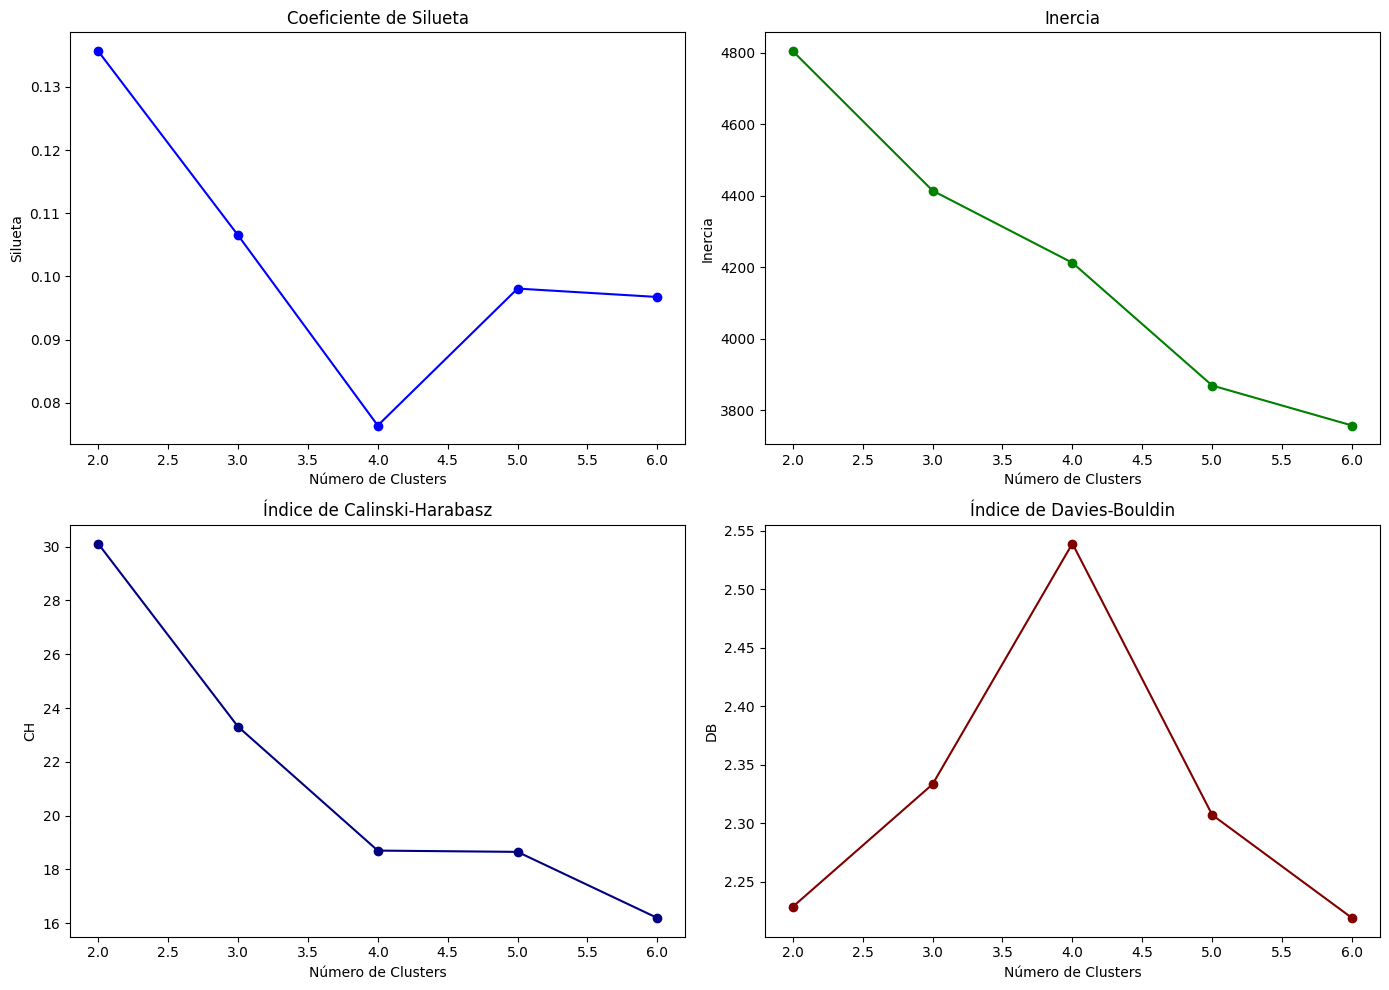

,Clusters,Silueta,Inercia,Calinski-Harabasz,Davies-Bouldin
0,2,0.135649,4804.410852,30.116167,2.228400
1,3,0.106535,4414.329244,23.311480,2.333131
2,4,0.076432,4212.772515,18.701909,2.538843
3,5,0.098087,3869.642521,18.653927,2.306946
4,6,0.096759,3757.972941,16.195832,2.218842


In [40]:
kmeans.optimal_clusters()

### Interpretación de Gráficos

* **Coeficiente de Silueta**. Un valor más alto habla de una mejor separación de los clusters, en este caso aunque mejora un poco el de 5 clusters no supera al de 2.

* **Inercia**. Mide la separación de los puntos con respecto sus centroides, siempre disminuye al aumentar los clusters aunque en este caso el nodo está entre 3 y 4.

* **Índice de Calinski–Harabasz (CH)**. Un valor más alto habla de clusters mejor definidos, nuevamente dos clusters vuelve a ser el mejor grupo de clusters a elegir.

* **Índice de Davies–Bouldin (DB)**. Entre más bajo hay una mejor separación entre clusters, en este caso 2 y 6 son los mejores valores, siendo el peor el de 4 clusters.

In [41]:
pca = PCA(n_components=0.9)  # conserva 90% de varianza
X_pca = pca.fit_transform(X_scaled)

X_data = X_pca  # si ya usaste PCA

best_score = -1
best_state = None
scores = []

# Probar múltiples semillas
for rs in range(100):
    kmeans_ = KMeans(n_clusters=2, random_state=rs, n_init=10)
    labels = kmeans_.fit_predict(X_data)
    score = silhouette_score(X_data, labels)
    scores.append((rs, score))
    
    if score > best_score:
        best_score = score
        best_state = rs

print(f"✅ Mejor silueta: {best_score:.4f} con random_state = {best_state}")

✅ Mejor silueta: 0.1372 con random_state = 11


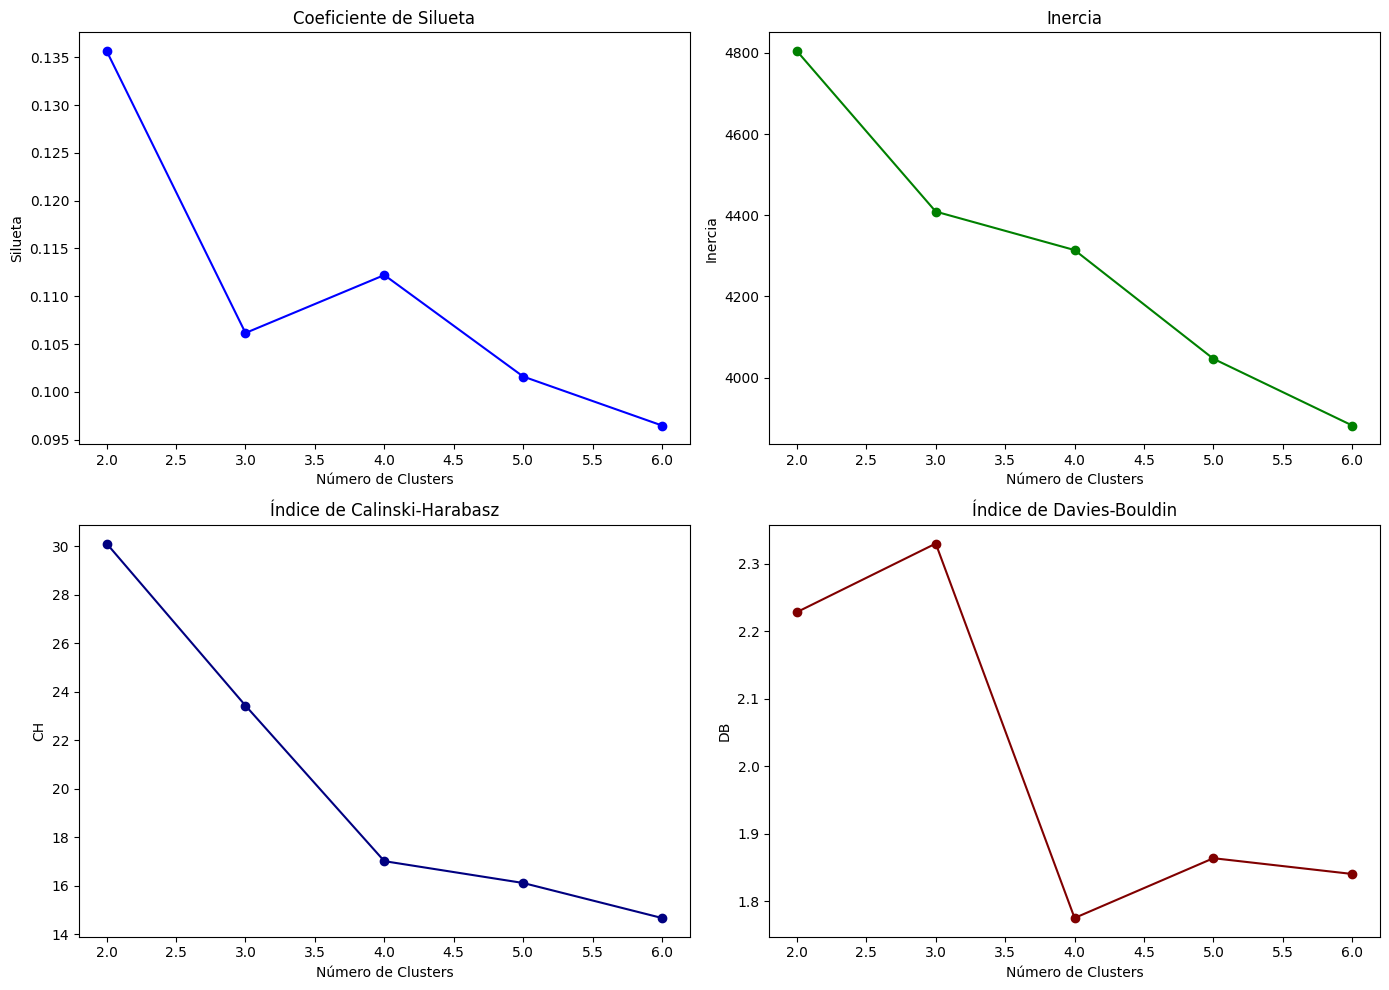

,Clusters,Silueta,Inercia,Calinski-Harabasz,Davies-Bouldin
0,2,0.135649,4804.410852,30.116167,2.228400
1,3,0.106163,4409.072854,23.434050,2.329979
2,4,0.112222,4314.311821,17.022217,1.775183
3,5,0.101610,4046.592685,16.121894,1.863789
4,6,0.096486,3882.283845,14.678215,1.840408


In [42]:
kmeans.optimal_clusters(11)

In [43]:
kmeans.fit(n_clusters=2, random_state=11)

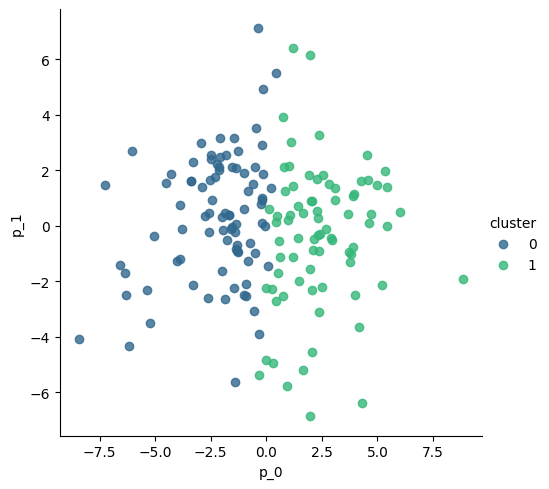

In [44]:
kmeans.plot(data)

In [45]:
songs1.reset_index(drop=True, inplace=True)

In [46]:
songs1['cluster'] = kmeans.get_df()['cluster']

In [47]:
pd.concat([songs1['cluster'].value_counts(), songs1['cluster'].value_counts(normalize=True).apply(lambda x: '{:.1%}'.format(x))], axis=1)

,count,proportion
cluster,,
0,85,52.5%
1,77,47.5%


## Playlist personalizada

### Variables significativas para una mejor separación de clusters

In [48]:
#Definimos un objeto para perfilamiento
class Perfil:
    def __init__(self, df, vars_cat, vars_cont, group_var='cluster'):
        self.df = df
        self.vars_cat = vars_cat
        self.vars_cont = vars_cont
        self.group_var = group_var

    def plot_dist(self, vars_cont: list | None = None):
        if vars_cont is None:
            vars_cont = self.vars_cont
        
        for var in vars_cont:
            plt.figure(figsize=(6, 4))
            sns.kdeplot(data=self.df, x=var, hue=self.group_var, common_norm=False, fill=True, alpha=0.4, palette='viridis')
            plt.title(f'Densidad de {var} por grupos')
            plt.xlabel(var)
            plt.ylabel(None)
            plt.tight_layout()
            plt.show()

    def kw_test(self):
        significativas = []
        for var in self.vars_cont:
            grupos = [grupo[var].dropna() for _, grupo in self.df.groupby(self.group_var)]
            stat, p = kruskal(*grupos)
            #if p < 0.05:
                #significativas.append((var, round(p, 5)))

            significativas.append((var, round(p, 5)))
            
        return pd.DataFrame(significativas, columns=['Variable', 'p-value'])
    
    def group_stats(self, vars):
        df_stats = self.df.groupby('cluster')[vars].agg(['mean', 'median', 'min', 'max'])
        df_stats.columns = ['_'.join(col) for col in df_stats.columns]
        df_stats.reset_index(inplace=True)
        return df_stats

In [49]:
perfil = Perfil(songs1, var_cat, var_num)

In [50]:
aux = perfil.kw_test().sort_values(by='p-value', ascending=False).reset_index(drop=True)

var_sig = aux.loc[aux['p-value'] < 0.05, "Variable"].tolist()
var_nosig = aux.loc[aux['p-value'] >= 0.05, "Variable"].tolist()

print('\nVariables no significativas\n')
display(aux.query(f"Variable == {var_nosig}"))

print('\nVariables significativas\n')
display(aux.query(f"Variable == {var_sig}"))


Variables no significativas



,Variable,p-value
0,tonnetz_6,0.96923
1,duration,0.70844
2,tempo_num,0.56595
3,tonnetz_4,0.55388
4,mfcc_5,0.49280
5,tonnetz_5,0.28999
6,mfcc_9,0.27942
7,tonnetz_3,0.20191
8,mfcc_3,0.08383
9,tonnetz_2,0.06198



Variables significativas



,Variable,p-value
12,zcr,0.03014
13,mfcc_7,0.02369
14,mfcc_1,0.00234
15,rms,0.00058
16,mfcc_13,0.00047
17,mfcc_4,0.00036
18,spectral_centroid,0.00000
19,chroma_10,0.00000
20,mfcc_12,0.00000
21,chroma_12,0.00000


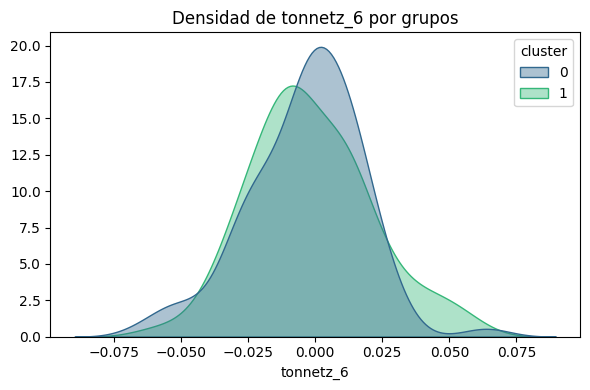

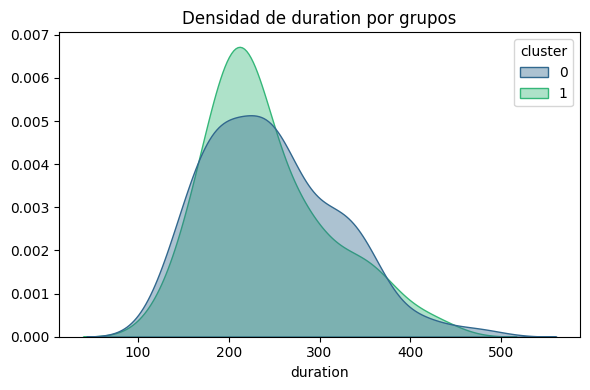

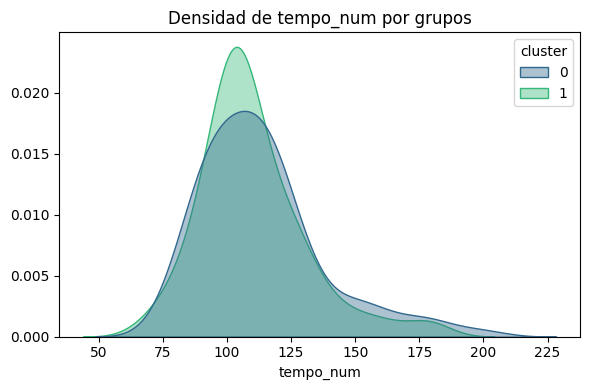

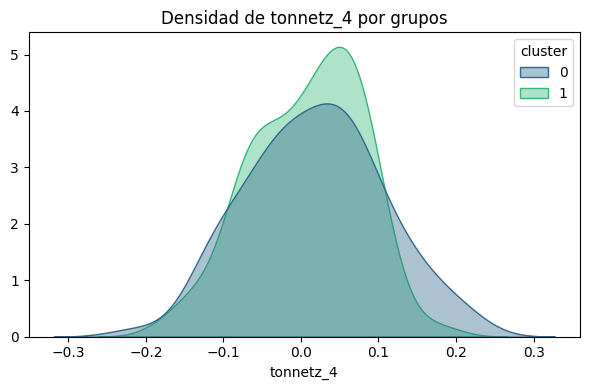

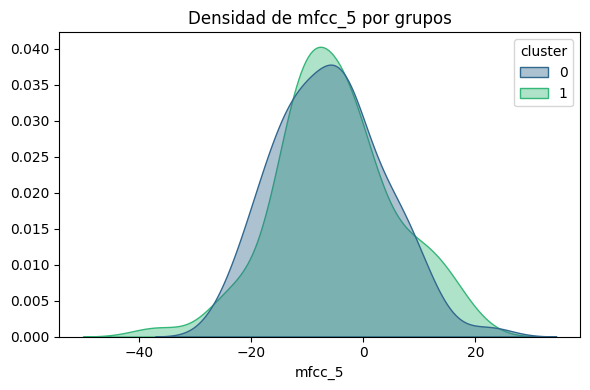

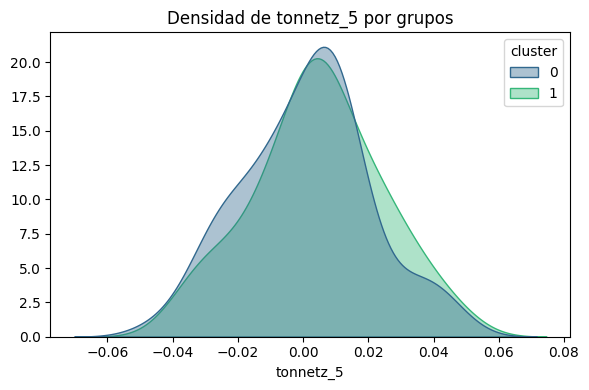

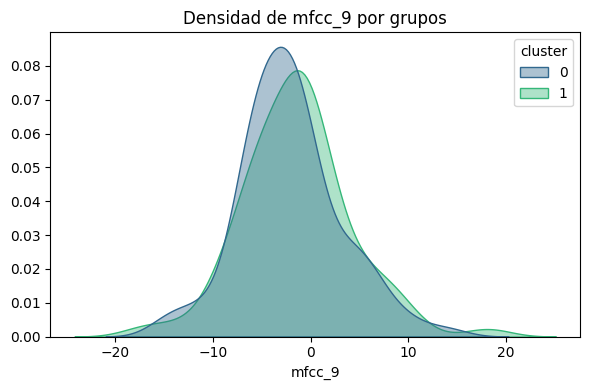

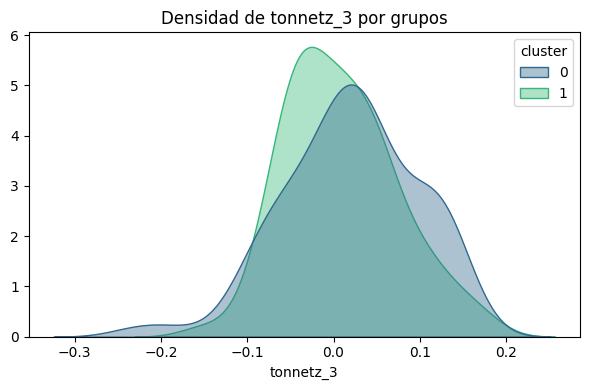

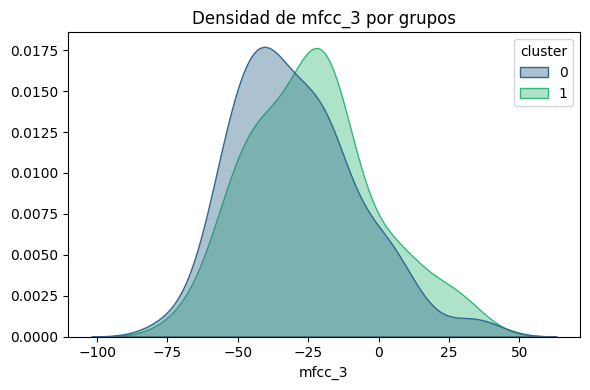

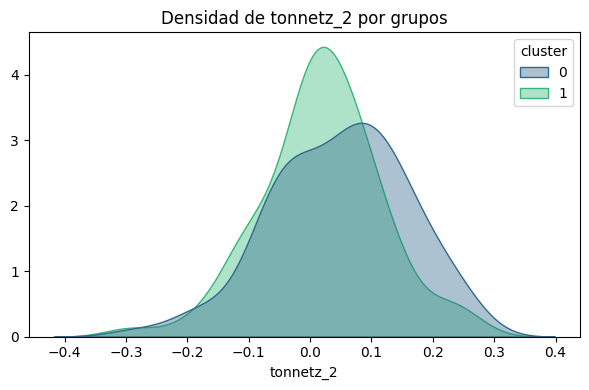

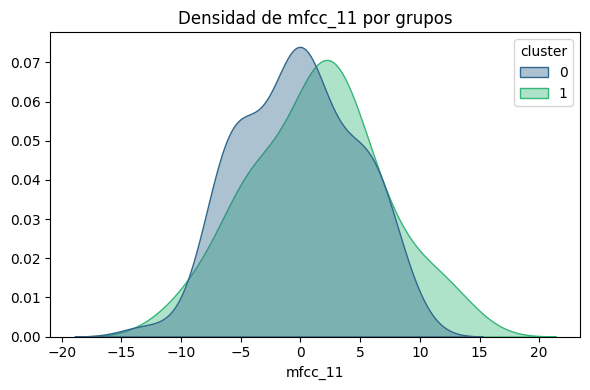

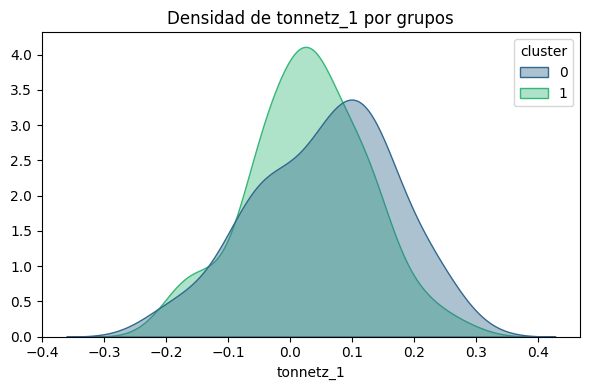

In [51]:
# Distribución de variables no significativas
perfil.plot_dist(var_nosig)

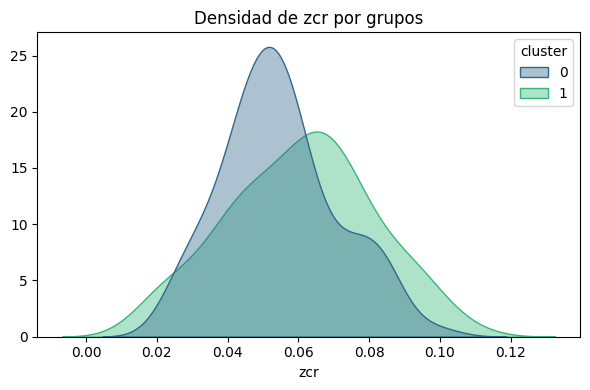

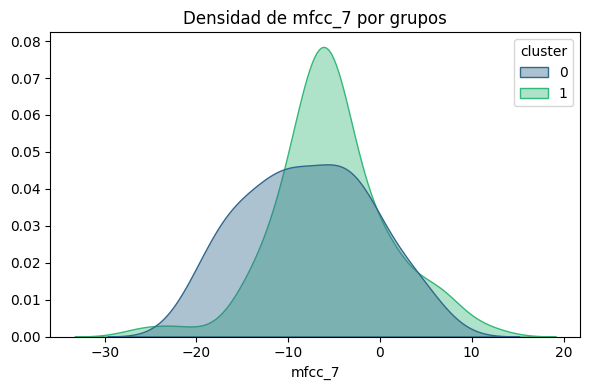

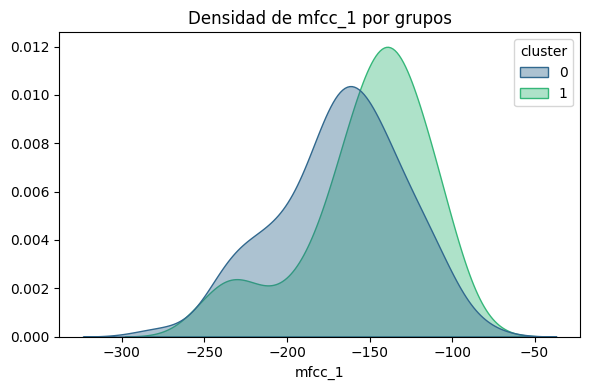

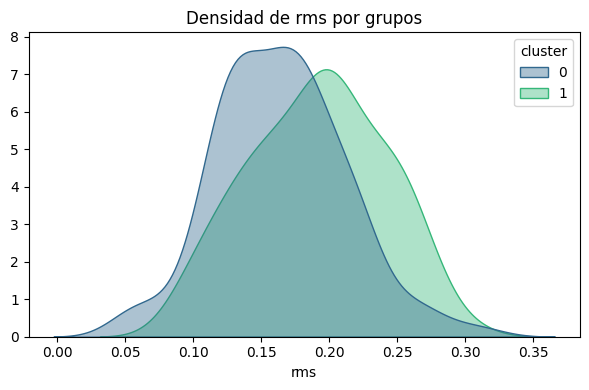

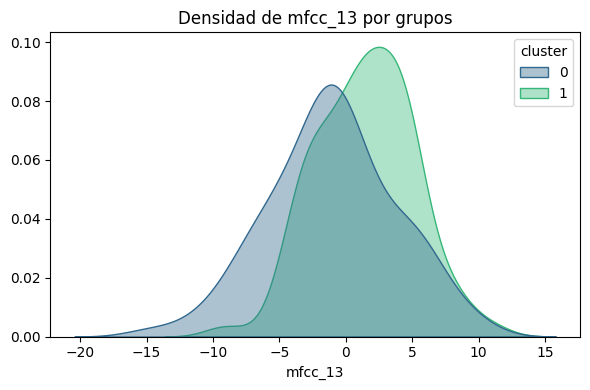

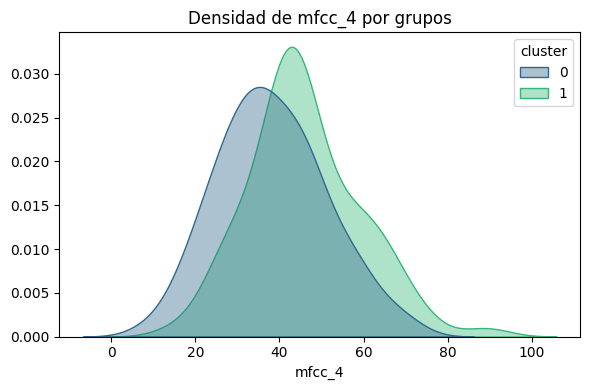

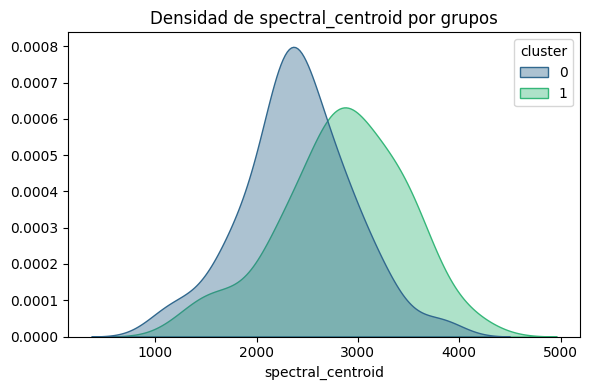

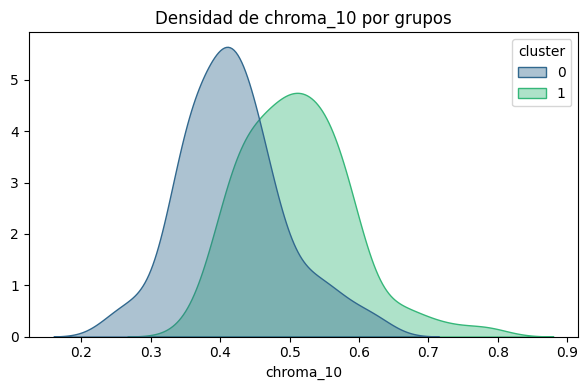

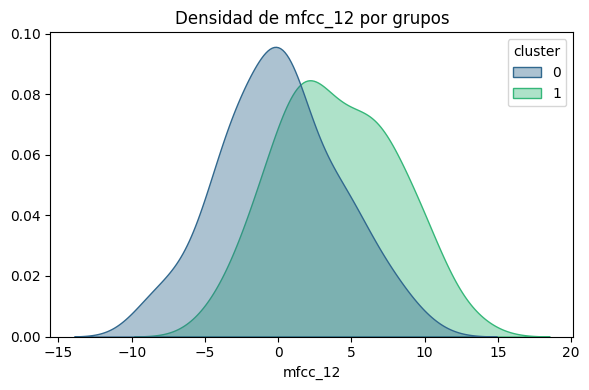

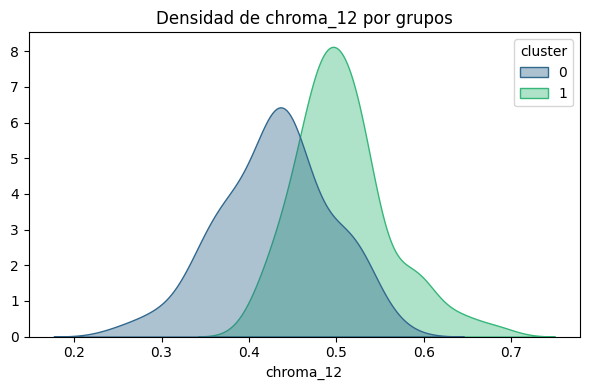

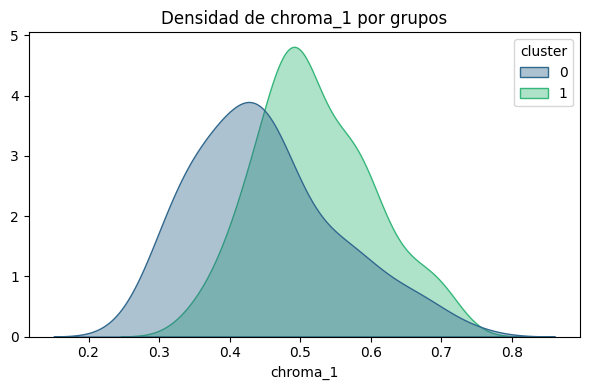

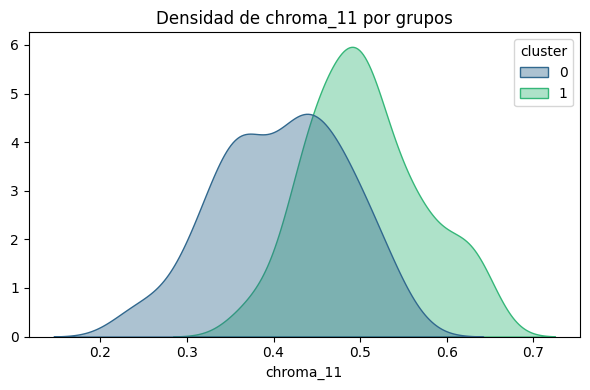

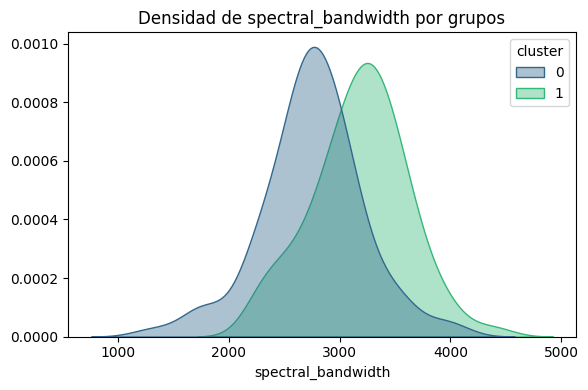

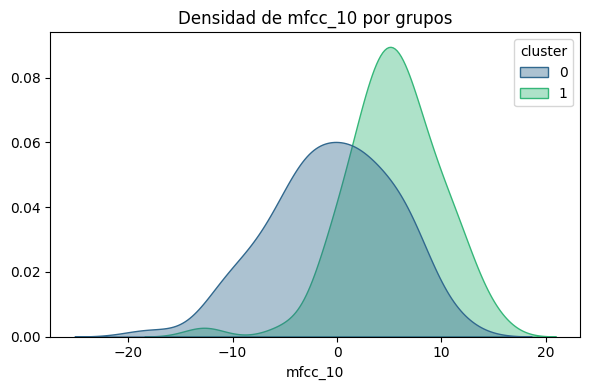

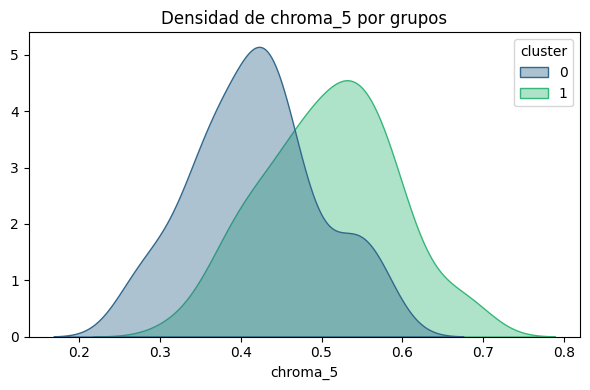

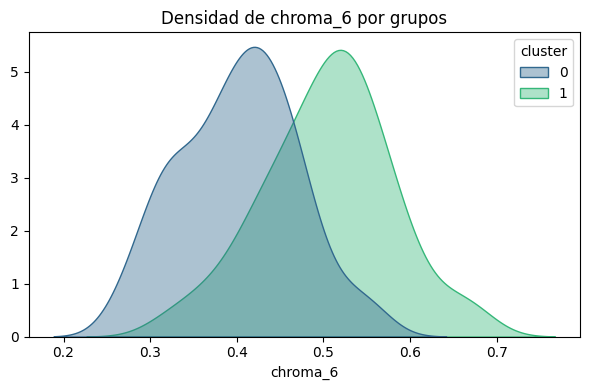

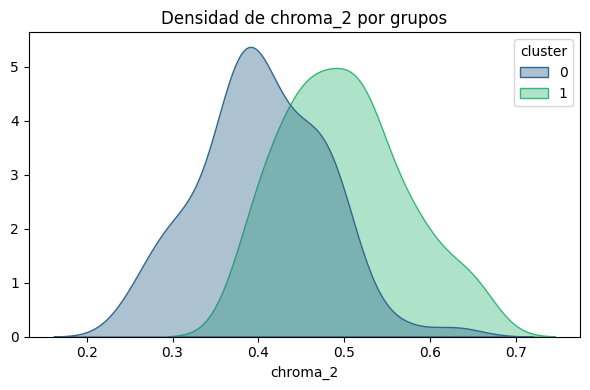

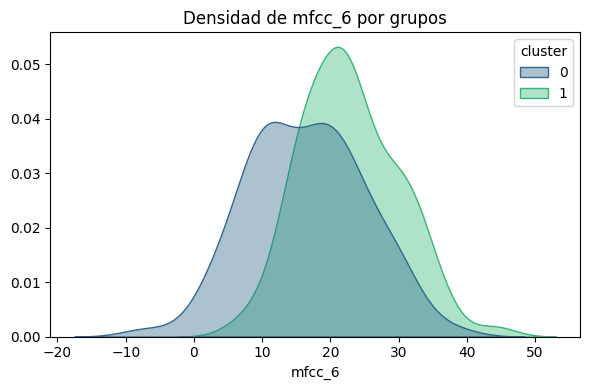

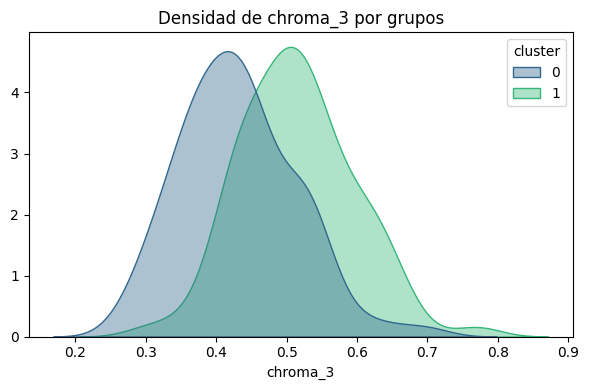

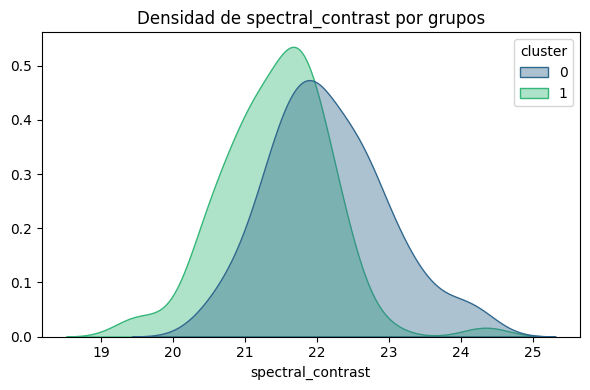

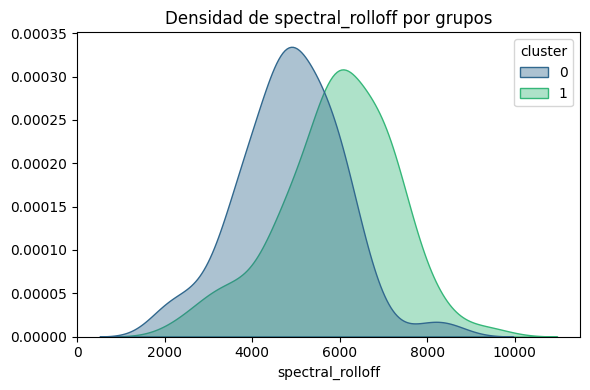

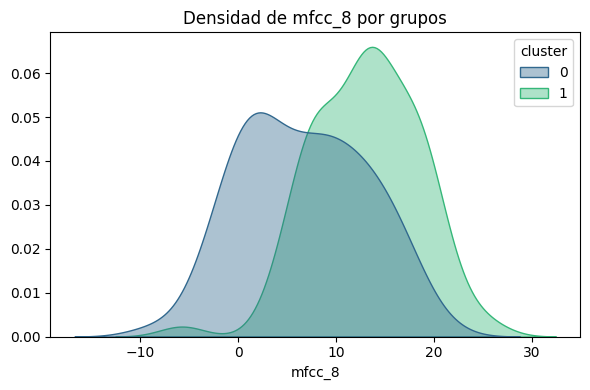

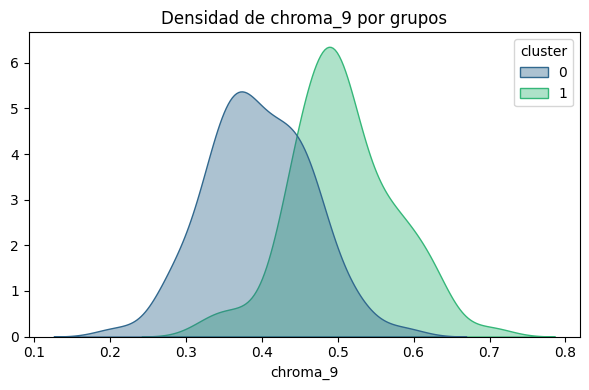

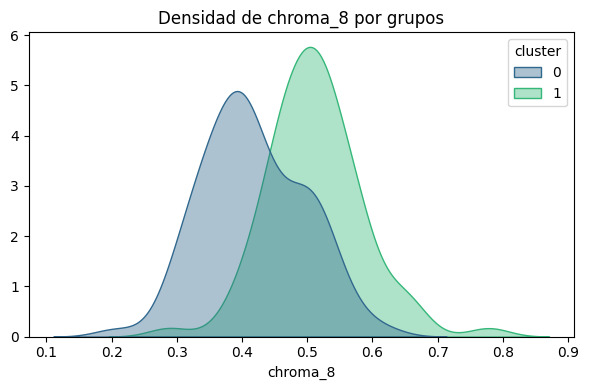

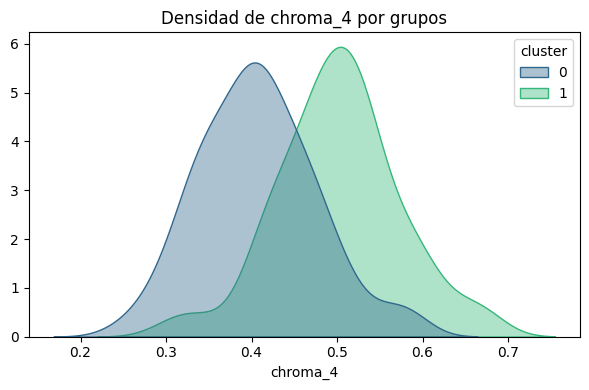

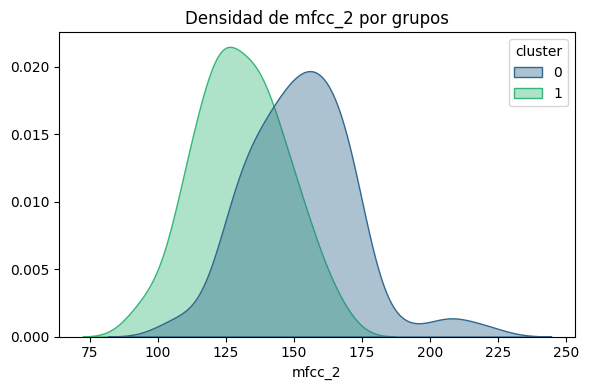

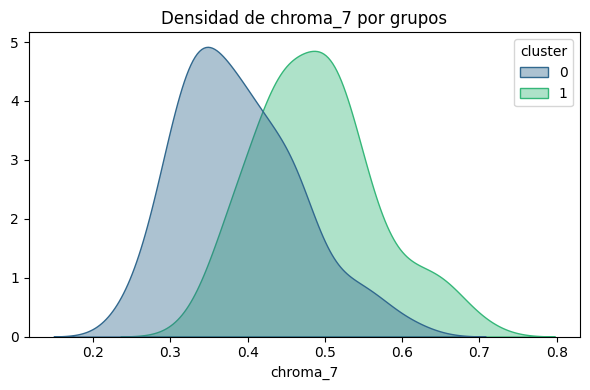

In [52]:
# Distribución de variables significativas
perfil.plot_dist(var_sig)

### Creación de variables categóricas para interpretación de resultados

### Tempo (BPM)

* Música popular: 60–180 BPM.
* Baladas: 60–90 BPM
* Pop/Rock: 100–140 BPM
* Electrónica/Dance: 120–150 BPM
* Trap/Drill/Reguetón: 70–100 BPM (a veces medido en doble tempo → 140–200).

### Zero Crossing Rate (ZCR)

* Normalizado entre 0 y 1.
* Voces limpias o instrumentos suaves: 0.02 – 0.1.
* Sonidos ruidosos/percusión fuerte: 0.1 – 0.3.
* Señales muy ruidosas pueden superar 0.4.

### Spectral Centroid

* Medido en Hz.
* Voces suaves: 1–2 kHz
* Música pop/rock promedio: 2–4 kHz
* Sonidos brillantes (platillos, electrónica): >5 kHz.
* Suele correlacionar con la “brillantez” del sonido.

In [53]:
def inferir_genero(row):
    t = row["tempo_num"]
    zcr = row["zcr"]
    sc = row["spectral_centroid"]

    # Balada
    if t <= 90 and zcr <= 0.1 and sc <= 2000:
        return "Balada / Música lenta"

    # Trap / Drill / Reguetón
    if (70 <= t <= 100 or 140 <= t <= 200) and 0.1 <= zcr <= 0.25 and sc <= 3000:
        return "Trap / Drill / Reguetón"

    # Pop / Rock
    if 100 < t <= 140 and 0.1 < zcr <= 0.3 and 2000 < sc <= 4000:
        return "Pop / Rock"

    # Electrónica / Dance
    if 120 <= t <= 150 and zcr >= 0.2 and sc > 4000:
        return "Electrónica / Dance"

    # Genérico
    return "Popular / Variada"

In [54]:
# Aplicar al DataFrame
songs1["genero_inferido"] = songs1.apply(inferir_genero, axis=1)

In [55]:
# Categorías para la variable tempo

bins_tempo = [0, 90, 120, 150, 1000]  # cortes
labels_tempo = ["Lento (≤90)", "Medio (90–120)", "Rápido (120–150)", "Muy rápido (>150)"]

songs1["tempo_cat"] = pd.cut(songs1["tempo_num"], bins=bins_tempo, labels=labels_tempo, ordered=True)

In [56]:
# Categorías para variable Zero crossing rate

bins_zcr = [0, 0.1, 0.3, 1.0]
labels_zcr = ["Bajo (≤0.1)", "Medio (0.1–0.3)", "Alto (>0.3)"]

songs1["zcr_cat"] = pd.cut(songs1["zcr"], bins=bins_zcr, labels=labels_zcr, ordered=True)

In [57]:
# Categorías para variable centroid

bins_centroid = [0, 2000, 4000, 10000]  
labels_centroid = ["Oscuro (≤2kHz)", "Equilibrado (2–4kHz)", "Brillante (>4kHz)"]

songs1["centroid_cat"] = pd.cut(songs1["spectral_centroid"], bins=bins_centroid, labels=labels_centroid, ordered=True)

In [58]:
from pandas.api.types import CategoricalDtype

class playlist:
    def __init__(self, df: pd.DataFrame, selection: list, sig_var: list, other_var: list, group_var: list | None = None):
        """
        Genera un resumen estadístico agrupado por una o varias columnas.
    
        Parámetros:
        -----------
        df : pd.DataFrame
            Dataset con las variables.
        other_var : list
            Columna(s) para agregar en la salida agrupada.
        group_var : str o list
            Columna(s) para agrupar (ej. 'cluster' o ['cluster','lang']).
        """
        
        self.df = df
        self.selection = selection
        self.sig_var = sig_var
        self.other_var = other_var
        self.group_var = ['cluster'] if group_var is None else group_var
    
    def agrupado(self, vars_num: list | None = None, agg: str = "mean", observed: bool = True):
        """
        Genera un resumen estadístico agrupado por una o varias columnas.
    
        Parámetros:
            -----------
        vars_num : list
            Lista de variables numéricas a resumir (si None, usa todas las numéricas).
        agg : str o list
            Agregación a aplicar ('mean', 'median', 'std', 'mode' o lista de funciones).
        
        Retorna:
        --------
        pd.DataFrame con estadísticas agrupadas.
        """
        
        if vars_num is None:
            vars_num = list(set(self.df.select_dtypes(include="number").columns.tolist())-set(self.group_var))
        
        # Si es moda, tratamos distinto porque mode() devuelve varias filas
        if agg == "mode":
            result = self.df.groupby(self.group_var, observed=observed)[vars_num].apply(lambda x: x.mode().iloc[0])
        else:
            result = self.df.groupby(self.group_var, observed=observed)[vars_num].agg(agg)
        
        #return result.reset_index()
        i = 0
        x = self.df.columns[i]
        
        while x in self.group_var:
            i += 1
            x = self.df.columns[i]
        
        return pd.concat([self.df.groupby(self.group_var, observed=observed).count()[x], result], axis=1) \
                        .rename(columns={x: 'count'}).reset_index()

        #return pd.concat([self.df.groupby(self.group_var, observed=observed).count()[], result], axis=1) \
            #.reset_index()
    
    def resumen(self, agg="mean", observed=True):
        pcolumns = self.other_var + list(set(self.sig_var)-set(self.other_var)-set(self.group_var))
        
        return self.agrupado(agg=agg, observed=observed)

    def select(self, i, return_count: bool = True):
        features = self.resumen().iloc[i, :].iloc[: len(self.group_var)].to_dict()

        # Crear la máscara booleana con "&"
        if self.group_var != ['cluster']:
            mask = (
                (self.df["cluster"] == features["cluster"]) &
                (self.df["lang"] == features["lang"]) &
                (self.df["genero_inferido"] == features["genero_inferido"]) &
                (self.df["tempo_cat"] == features["tempo_cat"])
            )
        else:
            mask = (
                self.df["cluster"] == features["cluster"]
            )
            
        df = self.df[mask].copy()   

        def str_duration(unidad: str, x: float):
            match unidad:
                case 's':
                    return f'{int(x/60)} min and {int(x%60)} s'
                case 'ms':
                    return f'{int(x/1000/60)} min and {int((x/1000)%60)} s'

        if 'duration' in df.columns:
            df['duration_min'] = df['duration'].apply(lambda x: str_duration('s', x))

        if 'spectral_centroid' in df.columns:
            df['spectral_centroid_kHz'] = df['spectral_centroid']/1000

        if 'spectral_rolloff' in df.columns:
            df['spectral_rolloff_kHz'] = df['spectral_rolloff']/1000

        if 'duration_ms' in df.columns:
            df['duration_min'] = df['duration_ms'].apply(lambda x: str_duration('ms', x))
        
        return df.loc[:, self.selection]
        

In [59]:
clase = playlist(
    df=songs1, 
    selection=['archivo', 'lang', 'genero_inferido', 'tempo_cat', 'duration_min', 'zcr', 'spectral_centroid', 'mfcc_7', 'mfcc_1', 'rms', 'mfcc_13', 'spectral_centroid_kHz', 'spectral_rolloff_kHz'],
    sig_var=var_sig,
    other_var=['tempo_num','spectral_centroid'],
    group_var=['cluster','lang','genero_inferido','tempo_cat']
)

In [60]:
clase.agrupado(agg='mean')

,cluster,lang,genero_inferido,tempo_cat,count,duration,rms,mfcc_4,tempo_num,chroma_12,...,chroma_10,zcr,spectral_centroid,tonnetz_4,chroma_5,chroma_11,spectral_bandwidth,mfcc_5,mfcc_10,tonnetz_3
0,0,Español,Popular / Variada,Lento (≤90),2,191.884002,0.135923,48.199354,88.347800,0.436333,...,0.424563,0.069367,2744.209058,0.001885,0.294393,0.504910,2927.815384,-5.262213,-2.987007,0.035136
1,0,Español,Popular / Variada,Medio (90–120),21,252.504737,0.173147,43.689703,102.984730,0.418787,...,0.421501,0.056751,2466.219131,0.042088,0.425515,0.403926,2735.968027,-5.124884,1.365021,0.013578
2,0,Español,Popular / Variada,Rápido (120–150),3,269.740423,0.161002,37.388587,125.248071,0.459106,...,0.400266,0.055584,2175.617833,0.068696,0.445772,0.432470,2383.529186,-3.033284,1.769222,0.059218
3,0,Inglés,Balada / Música lenta,Lento (≤90),1,184.041361,0.224655,26.937143,86.132812,0.524760,...,0.469983,0.034992,1862.020089,0.053310,0.472580,0.520098,2612.166207,-6.117527,6.262030,0.040727
4,0,Inglés,Popular / Variada,Lento (≤90),8,243.139663,0.148802,39.981222,83.643979,0.433606,...,0.423544,0.057418,2520.394853,0.001604,0.376035,0.381875,2787.981519,-9.507221,-3.103913,0.050455
5,0,Inglés,Popular / Variada,Medio (90–120),29,242.418344,0.158530,35.904603,106.537676,0.433243,...,0.426969,0.054139,2442.431392,-0.003242,0.422260,0.405923,2878.859949,-7.944314,-0.057413,-0.002409
6,0,Inglés,Popular / Variada,Rápido (120–150),14,247.453567,0.168425,36.517796,131.501717,0.434878,...,0.403819,0.052285,2242.195715,0.031007,0.445410,0.408565,2582.045832,-1.494251,-0.552511,0.018393
7,0,Inglés,Popular / Variada,Muy rápido (>150),7,263.444536,0.172428,31.092083,172.149318,0.403283,...,0.382129,0.049383,2267.383886,-0.001810,0.393233,0.416404,2692.007068,-7.617173,-5.611111,0.069671
8,1,Español,Popular / Variada,Lento (≤90),3,218.567203,0.213299,52.145625,86.181503,0.489627,...,0.524737,0.060058,2836.643502,-0.009711,0.490979,0.517017,3175.858852,-4.132424,2.448277,0.039002
9,1,Español,Popular / Variada,Medio (90–120),7,219.629397,0.161042,46.714186,99.900158,0.464074,...,0.459733,0.065021,2976.125451,-0.020939,0.433873,0.496584,3261.073596,-6.705578,5.482506,0.042829


### Selección de grupo de canciones

In [61]:
print(clase.select(5).shape[0], "canciones del grupo de la fila 5 de la tabla anterior, a continuación se muestra el top 5 ordenado por la métrica ZCR.\n")
clase.select(5).sort_values(by=['zcr']).reset_index(drop=True).head() # seleeción de una fila de la tabla anterior

29 canciones del grupo de la fila 5 de la tabla anterior, a continuación se muestra el top 5 ordenado por la métrica ZCR.



,archivo,lang,genero_inferido,tempo_cat,duration_min,zcr,spectral_centroid,mfcc_7,mfcc_1,rms,mfcc_13,spectral_centroid_kHz,spectral_rolloff_kHz
0,8 my boy only breaks his favorite toys (first ...,Inglés,Popular / Variada,Medio (90–120),3 min and 11 s,0.026073,1206.772573,-2.028812,-207.29584,0.212049,-8.893036,1.206773,2.200230
1,04 snow on the beach,Inglés,Popular / Variada,Medio (90–120),4 min and 16 s,0.026679,1691.923217,-5.396293,-205.33786,0.191276,0.654356,1.691923,3.338831
2,10 labyrinth,Inglés,Popular / Variada,Medio (90–120),4 min and 8 s,0.028861,1512.256993,-5.439651,-239.80269,0.116779,-0.800612,1.512257,2.888892
3,12 sweet nothing,Inglés,Popular / Variada,Medio (90–120),3 min and 8 s,0.028935,1549.530534,-10.776519,-276.42240,0.134137,-2.024282,1.549531,3.173259
4,20 snow on the beach (feat. more lana del rey),Inglés,Popular / Variada,Medio (90–120),3 min and 50 s,0.032701,1847.973731,-6.170126,-175.40880,0.194155,-1.098595,1.847974,3.743683


In [62]:
def str_duration(x: float):
    return f'{int(x/60)} min and {int(x%60)} s'

In [63]:
songs1['duration'].describe().loc[['mean','min','25%','50%','75%','max']].map(str_duration)

mean     4 min and 4 s
min      2 min and 4 s
25%     3 min and 11 s
50%     3 min and 50 s
75%     4 min and 46 s
max     7 min and 52 s
Name: duration, dtype: object

## Conclusión

El estudio muestra que la mayoría de las canciones analizadas están en idioma inglés y presentan una duración promedio de 3 a 4 minutos, en concordancia con los estándares de la música popular contemporánea. Al examinar los resultados de la segmentación, se observa que, dentro de ciertos clusters que agrupan entre 20 y 40 canciones en inglés, al menos 10 corresponden a artistas reconocidos del pop moderno, como Taylor Swift o Sabrina Carpenter. Este hallazgo no solo refuerza la pertinencia de la categoría inferida “popular/variada”, sino que además aporta evidencia empírica que vincula los clusters obtenidos con tendencias musicales actuales y artistas de referencia en el género.

Algunas variables que podrían enriquecer la interpretación son:

1. Artista
2. Género musical
3. Año de lanzamiento
4. Idioma de la canción (Español, Inglés, etc.)
5. Reproducciones mensuales

Y otras variables que podrían enriquecer el clustering son:

1. **Loudness (LUFS o dBFS)**. Nivel de volumen percibido promedio, ayuda a diferenciar baladas suaves vs. música muy producida y comprimida.
2. **Danceability (0–1)**. Méide cuán adecuada es una pista para bailar según ritmo, estabilidad y beat.
3. **Valence (0–1)**. Mide si la canción transmite emociones positivas (alegría) o negativas (tristeza).
4. **Energy (0–1)**. Similar a RMS pero ajustado a percepción humana; distingue baladas tranquilas de temas electrónicos potentes.
5. **Instrumentalness (0–1)**. Probabilidad de que la pista sea instrumental (sin voz).
6. **Speechiness (0–1)**. Proporción de voz hablada/rap frente a canto melódico.
7. **Acousticness (0–1)**. Probabilidad de que la canción sea acústica vs. electrónica/producida.
8. **Pitch-related features (si quisieras derivar más de Chroma/Tonnetz)**.Porcentaje de notas mayores vs menores, que puede asociarse a emociones.

# Ejercicio 2

## Cargar datos

In [64]:
# !pip install openpyxl
songs2 = pd.read_excel(r'https://raw.githubusercontent.com/Wsm-erick/Diplomado/refs/heads/main/Modulo-I/Datasets/audio_features_lyrics.xlsx')

In [65]:
songs2.shape

(18172, 32)

In [66]:
songs2.head()

,album_name,ep,album_release,track_number,track_name,artist,featuring,bonus_track,promotional_release,single_release,...,time_signature,duration_ms,explicit,key_name,mode_name,key_mode,line,lyric,element,element_artist
0,Taylor Swift,0.0,2006-10-24,1.0,Tim McGraw,Taylor Swift,NaN,0.0,NaT,2006-06-19,...,4.0,232107.0,0.0,C,major,C major,1,He said the way my blue eyes shined,Verse 1,Taylor Swift
1,Taylor Swift,0.0,2006-10-24,1.0,Tim McGraw,Taylor Swift,NaN,0.0,NaT,2006-06-19,...,4.0,232107.0,0.0,C,major,C major,2,Put those Georgia stars to shame that night,Verse 1,Taylor Swift
2,Taylor Swift,0.0,2006-10-24,1.0,Tim McGraw,Taylor Swift,NaN,0.0,NaT,2006-06-19,...,4.0,232107.0,0.0,C,major,C major,3,"I said, ""That's a lie""",Verse 1,Taylor Swift
3,Taylor Swift,0.0,2006-10-24,1.0,Tim McGraw,Taylor Swift,NaN,0.0,NaT,2006-06-19,...,4.0,232107.0,0.0,C,major,C major,4,Just a boy in a Chevy truck,Verse 1,Taylor Swift
4,Taylor Swift,0.0,2006-10-24,1.0,Tim McGraw,Taylor Swift,NaN,0.0,NaT,2006-06-19,...,4.0,232107.0,0.0,C,major,C major,5,That had a tendency of gettin' stuck,Verse 1,Taylor Swift


## Descripción de las variables

![descimg1](songs2_var_description.png)
![descimg2](songs2_var_description2.png)
![descimg3](songs2_var_description3.png)
![descimg4](songs2_var_description4.png)

## Actividad

![actimg1](songs2_activity.png)
![actimg2](songs2_activity2.png)

In [67]:
songs2.tail(2)

,album_name,ep,album_release,track_number,track_name,artist,featuring,bonus_track,promotional_release,single_release,...,time_signature,duration_ms,explicit,key_name,mode_name,key_mode,line,lyric,element,element_artist
18170,NaN,NaN,NaT,NaN,You'll Always Find Your Way Back Home,Hannah Montana,NaN,NaN,NaT,2009-03-24,...,4.0,224187.0,0.0,G#,major,G# major,58,"You'll always, you'll always find your way",Outro,Taylor Swift
18171,NaN,NaN,NaT,NaN,You'll Always Find Your Way Back Home,Hannah Montana,NaN,NaN,NaT,2009-03-24,...,4.0,224187.0,0.0,G#,major,G# major,59,You'll always find your way (Back home) back home,Outro,Taylor Swift


## Exploración

In [68]:
songs2.iloc[:100].to_csv('muestra_dataset2.csv')

### Valores ausentes

In [69]:
is_na_df(songs2)

,columna,n_missing,total,prop_missing,prop_original
0,album_name,1779,18172,0.097898,0.902102
1,ep,1779,18172,0.097898,0.902102
2,album_release,1779,18172,0.097898,0.902102
3,track_number,1779,18172,0.097898,0.902102
4,featuring,15898,18172,0.874862,0.125138
5,bonus_track,1779,18172,0.097898,0.902102
6,promotional_release,15836,18172,0.871451,0.128549
7,single_release,14222,18172,0.782633,0.217367
8,danceability,579,18172,0.031862,0.968138
9,energy,579,18172,0.031862,0.968138


In [70]:
is_na_df(songs2).query('prop_missing > 0.15')

,columna,n_missing,total,prop_missing,prop_original
4,featuring,15898,18172,0.874862,0.125138
6,promotional_release,15836,18172,0.871451,0.128549
7,single_release,14222,18172,0.782633,0.217367


In [71]:
print('Moda: {0:.2%}'.format(stats.mode(is_na_df(songs2).prop_missing)[0]))
print('Media: {0:.2%}'.format(np.mean(is_na_df(songs2).prop_missing)))

Moda: 3.19%
Media: 14.12%


Tenemos 11% de valores ausentes en total del dataset, la moda de valores ausentes es de 3.19%. La media se eleva a 14.12% por variables como featuring, promotional_release y single_release que tienen más del 75% de valores ausentes, vamos a revisar si es necesario eliminar dichas variables.

In [72]:
dict_single_release = {x: i for i, x in enumerate(songs2['single_release'].unique().dropna())}
songs2['single_release_rec'] = songs2['single_release'].map(dict_single_release)
songs2.groupby('track_name')['single_release_rec'].mean().map(lambda x: 1 if x >= 0 else 'nan').value_counts()

single_release_rec
nan    287
1       76
Name: count, dtype: int64

In [73]:
dict_promotional_release = {x: i for i, x in enumerate(songs2['promotional_release'].unique().dropna())}
songs2['promotional_release_rec'] = songs2['promotional_release'].map(dict_promotional_release)
songs2.groupby('track_name')['promotional_release_rec'].mean().map(lambda x: 1 if x >= 0 else 'nan').value_counts()

promotional_release_rec
nan    318
1       45
Name: count, dtype: int64

In [74]:
dict_featuring = {x: i for i, x in enumerate(pd.Series(songs2['featuring'].unique()).dropna())}

print('Artistas que cantaron con Taylor en la pista:', len(dict_featuring))

songs2['featuring_rec'] = songs2['featuring'].map(dict_featuring)
songs2.groupby('track_name')['featuring_rec'].mean().map(lambda x: 1 if x >= 0 else 'nan').value_counts()

Artistas que cantaron con Taylor en la pista: 27


featuring_rec
nan    319
1       44
Name: count, dtype: int64

 Los conteos anteriores confirman que conviene eliminarlas debido a su alta concentración de valores ausentes (>15%).

In [75]:
songs2.drop(['featuring','promotional_release','single_release','featuring_rec','promotional_release_rec','single_release_rec'], axis=1, inplace=True)

In [76]:
print('Media: {0:.2%}'.format(np.mean(is_na_df(songs2).prop_missing)))

Media: 4.64%


Eliminando esas variables ya vemos que la media de valores ausentes se asimila a la moda.

### Tipo de dato por variable

In [77]:
songs2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18172 entries, 0 to 18171
Data columns (total 29 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   album_name        16393 non-null  object        
 1   ep                16393 non-null  float64       
 2   album_release     16393 non-null  datetime64[ns]
 3   track_number      16393 non-null  float64       
 4   track_name        18172 non-null  object        
 5   artist            18172 non-null  object        
 6   bonus_track       16393 non-null  float64       
 7   track_release     18172 non-null  datetime64[ns]
 8   danceability      17593 non-null  float64       
 9   energy            17593 non-null  float64       
 10  key               17593 non-null  float64       
 11  loudness          17593 non-null  float64       
 12  mode              17593 non-null  float64       
 13  speechiness       17593 non-null  float64       
 14  acousticness      1759

In [78]:
# Clave o llave del track para agrupar líneas de letras (si hay varias filas por canción)
track_key = ["artist","album_name","track_number","track_name"]
track_key = [c for c in track_key if c in songs2.columns]

In [79]:
track_key

['artist', 'album_name', 'track_number', 'track_name']

In [80]:
songs2.loc[:, track_key]

,artist,album_name,track_number,track_name
0,Taylor Swift,Taylor Swift,1.0,Tim McGraw
1,Taylor Swift,Taylor Swift,1.0,Tim McGraw
2,Taylor Swift,Taylor Swift,1.0,Tim McGraw
3,Taylor Swift,Taylor Swift,1.0,Tim McGraw
4,Taylor Swift,Taylor Swift,1.0,Tim McGraw
...,...,...,...,...
18167,Hannah Montana,NaN,NaN,You'll Always Find Your Way Back Home
18168,Hannah Montana,NaN,NaN,You'll Always Find Your Way Back Home
18169,Hannah Montana,NaN,NaN,You'll Always Find Your Way Back Home
18170,Hannah Montana,NaN,NaN,You'll Always Find Your Way Back Home


In [81]:
songs2[songs2['track_name']=="You'll Always Find Your Way Back Home"].head()

,album_name,ep,album_release,track_number,track_name,artist,bonus_track,track_release,danceability,energy,...,time_signature,duration_ms,explicit,key_name,mode_name,key_mode,line,lyric,element,element_artist
18113,NaN,NaN,NaT,NaN,You'll Always Find Your Way Back Home,Hannah Montana,NaN,2009-03-24,0.577,0.906,...,4.0,224187.0,0.0,G#,major,G# major,1,Woo!,Intro,Taylor Swift
18114,NaN,NaN,NaT,NaN,You'll Always Find Your Way Back Home,Hannah Montana,NaN,2009-03-24,0.577,0.906,...,4.0,224187.0,0.0,G#,major,G# major,2,You wake up,Verse 1,Taylor Swift
18115,NaN,NaN,NaT,NaN,You'll Always Find Your Way Back Home,Hannah Montana,NaN,2009-03-24,0.577,0.906,...,4.0,224187.0,0.0,G#,major,G# major,3,It's raining and it's Monday,Verse 1,Taylor Swift
18116,NaN,NaN,NaT,NaN,You'll Always Find Your Way Back Home,Hannah Montana,NaN,2009-03-24,0.577,0.906,...,4.0,224187.0,0.0,G#,major,G# major,4,Looks like one of those rough days,Verse 1,Taylor Swift
18117,NaN,NaN,NaT,NaN,You'll Always Find Your Way Back Home,Hannah Montana,NaN,2009-03-24,0.577,0.906,...,4.0,224187.0,0.0,G#,major,G# major,5,Time's up,Verse 1,Taylor Swift


In [82]:
songs2[songs2['track_name']=="You'll Always Find Your Way Back Home"].shape

(59, 29)

In [83]:
songs2[songs2['track_name']=="You'll Always Find Your Way Back Home"]['line'].max()

59

El dataset viene a nivel lírica o línea de cada canción por lo que establecimos 'artist', 'album_name', 'track_number', 'track_name' como la llave para agrupar y obtener las características o métricas de cada canción para poder clusterizar.

In [84]:
songs2.query("artist == 'Taylor Swift'", inplace=True) # canciones de taylor swift como artista principal

In [85]:
songs2['artist'].unique() # validación que sólo traigamos a Taylor como artista

array(['Taylor Swift'], dtype=object)

In [86]:
songs2.shape # dimensión

(17204, 29)

## Tratamiento de Datos

### Funciones para obtener métricas de la letra y canciones

In [87]:
# instalar en primera ejecución
# nltk.download("stopwords"); nltk.download("punkt"); nltk.download('punkt_tab')

In [88]:
# campos principales (llave) por canción
track_key = [c for c in ["artist","album_name","track_number","track_name"] if c in songs2.columns]

# stopwords y vocales
stop_es = set(stopwords.words("spanish"))
stop_en = set(stopwords.words("english"))
stop_all = stop_es | stop_en

_vowels = re.compile(r"[aeiouáéíóúü]+", re.IGNORECASE)

def count_syllables(word: str) -> int:
    return max(1, len(_vowels.findall(word)))

def text_features(s: str) -> dict:
    if not isinstance(s, str) or not s.strip():
        return {"n_words":0,"n_unique":0,"lex_density":0.0,"avg_word_len":0.0,"avg_syllables":0.0,"stop_ratio":0.0}
    toks = [t.lower() for t in word_tokenize(s) if re.match(r"\w+", t)]
    if not toks:
        return {"n_words":0,"n_unique":0,"lex_density":0.0,"avg_word_len":0.0,"avg_syllables":0.0,"stop_ratio":0.0}

    n_words = len(toks)
    unique = len(set(toks))
    avg_len = float(np.mean([len(w) for w in toks]))
    avg_syl = float(np.mean([count_syllables(w) for w in toks]))
    n_stop = sum(w in stop_all for w in toks)
    lex_density = 1 - (n_stop / n_words)
    stop_ratio = n_stop / n_words

    return {
        "n_words": n_words,
        "n_unique": unique,
        "lex_density": lex_density,
        "avg_word_len": avg_len,
        "avg_syllables": avg_syl,
        "stop_ratio": stop_ratio,
    }


In [89]:
# Métricas de letra por canción

agg_text = ( 
    songs2.groupby(track_key)["lyric"] 
      .apply(lambda s: "\n".join(s.dropna().astype(str)))  # concatenar letra completa
      .reset_index()
)

agg_text["n_lines"] = agg_text["lyric"].str.count(r"\n").fillna(0).astype(int) # líneas por canción
agg_text_feats = agg_text["lyric"].apply(text_features).apply(pd.Series) # features de la letra
agg_text["lyric"] = agg_text["lyric"].str.replace('\n', ' ') # sustituir saltos de línea por espacios
agg_text = pd.concat([agg_text[track_key + ['lyric','n_lines']], agg_text_feats], axis=1) # concatenar features de la letra por canción

print('Dimensión', agg_text.shape, end='\n\n')
display(agg_text.head(3))

Dimensión (326, 12)



,artist,album_name,track_number,track_name,lyric,n_lines,n_words,n_unique,lex_density,avg_word_len,avg_syllables,stop_ratio
0,Taylor Swift,1989,1.0,Welcome To New York,"Walking through a crowd, the village is aglow ...",43,348.0,91.0,0.557471,4.135057,1.399425,0.442529
1,Taylor Swift,1989,2.0,Blank Space,"Nice to meet you, where you been? I could show...",83,509.0,175.0,0.514735,3.555992,1.249509,0.485265
2,Taylor Swift,1989,3.0,Style,"Midnight You come and pick me up, no headlight...",47,383.0,120.0,0.522193,3.605744,1.245431,0.477807


In [90]:
# Proporción de elementos (coro, verso, intro…)
elem_props = (
    songs2.groupby(track_key + ["element"]).size().unstack(fill_value=0)
)
elem_props = elem_props.div(elem_props.sum(axis=1), axis=0)  # normalizar a proporciones
elem_props.columns = [f"elem_prop_{c}" for c in elem_props.columns]

print('Dimensión', elem_props.shape, end='\n\n')
display(elem_props.head(3))

Dimensión (326, 29)



elem_prop_Break  \
artist       album_name track_number track_name                             
Taylor Swift 1989       1.0          Welcome To New York              0.0   
                        2.0          Blank Space                      0.0   
                        3.0          Style                            0.0   

                                                          elem_prop_Breakdown  \
artist       album_name track_number track_name                                 
Taylor Swift 1989       1.0          Welcome To New York                  0.0   
                        2.0          Blank Space                          0.0   
                        3.0          Style                                0.0   

                                                          elem_prop_Bridge  \
artist       album_name track_number track_name                              
Taylor Swift 1989       1.0          Welcome To New York          0.090909   
                        2.0          Blank Space                  0.047619   
                        3.0          Style                        0.104167   

                                                          elem_prop_Bridge 1  \
artist       album_name track_number track_name                                
Taylor Swift 1989       1.0          Welcome To New York                 0.0   
                        2.0          Blank Space                         0.0   
                        3.0          Style                               0.0   

                                                          elem_prop_Bridge 2  \
artist       album_name track_number track_name                                
Taylor Swift 1989       1.0          Welcome To New York                 0.0   
                        2.0          Blank Space                         0.0   
                        3.0          Style                               0.0   

                                                          elem_prop_Buildup  \
artist       album_name track_number track_name                               
Taylor Swift 1989       1.0          Welcome To New York                0.0   
                        2.0          Blank Space                        0.0   
                        3.0          Style                              0.0   

                                                          elem_prop_Chorus  \
artist       album_name track_number track_name                              
Taylor Swift 1989       1.0          Welcome To New York          0.681818   
                        2.0          Blank Space                  0.571429   
                        3.0          Style                        0.479167   

                                                          elem_prop_Chorus - Variation  \
artist       album_name track_number track_name                                          
Taylor Swift 1989       1.0          Welcome To New York                           0.0   
                        2.0          Blank Space                                   0.0   
                        3.0          Style                                         0.0   

                                                          elem_prop_Chorus 1  \
artist       album_name track_number track_name                                
Taylor Swift 1989       1.0          Welcome To New York                 0.0   
                        2.0          Blank Space                         0.0   
                        3.0          Style                               0.0   

                                                          elem_prop_Chorus 2  \
artist       album_name track_number track_name                                
Taylor Swift 1989       1.0          Welcome To New York                 0.0   
                        2.0          Blank Space                         0.0   
                        3.0          Style                               0.0   

                                 

In [91]:
# Variables musicales (se repiten en todas las líneas → tomar promedio o el primero)

music_feats = (
    songs2.groupby(track_key)
      [["danceability","energy","valence","tempo","duration_ms","acousticness","instrumentalness","liveness"]]
      .mean()
)

print('Dimensión', music_feats.shape, end='\n\n')
display(music_feats.head(3))

Dimensión (326, 8)



danceability  \
artist       album_name track_number track_name                          
Taylor Swift 1989       1.0          Welcome To New York         0.789   
                        2.0          Blank Space                 0.760   
                        3.0          Style                       0.588   

                                                          energy  valence  \
artist       album_name track_number track_name                             
Taylor Swift 1989       1.0          Welcome To New York   0.634    0.658   
                        2.0          Blank Space           0.703    0.570   
                        3.0          Style                 0.791    0.487   

                                                            tempo  \
artist       album_name track_number track_name                     
Taylor Swift 1989       1.0          Welcome To New York  116.992   
                        2.0          Blank Space           95.997   
                        3.0          Style                 94.933   

                                                          duration_ms  \
artist       album_name track_number track_name                         
Taylor Swift 1989       1.0          Welcome To New York     212600.0   
                        2.0          Blank Space             231827.0   
                        3.0          Style                   231000.0   

                                                          acousticness  \
artist       album_name track_number track_name                          
Taylor Swift 1989       1.0          Welcome To New York       0.03480   
                        2.0          Blank Space               0.10300   
                        3.0          Style                     0.00245   

                                                          instrumentalness  \
artist       album_name track_number track_name                              
Taylor Swift 1989       1.0          Welcome To New York          0.000002   
                        2.0          Blank Space                  0.000000   
                        3.0          Style                        0.002580   

                                                          liveness  
artist       album_name track_number track_name                     
Taylor Swift 1989       1.0          Welcome To New York    0.3020  
                        2.0          Blank Space            0.0913  
                        3.0          Style                  0.1180

In [92]:
# Variables categóricas

cat_feats = (
    songs2.groupby(track_key)
      [["explicit","mode","time_signature"]]
      .mean()
)

print('Dimensión:', cat_feats.shape, end='\n\n')
display(cat_feats.head(3))

Dimensión: (326, 3)



explicit  mode  \
artist       album_name track_number track_name                            
Taylor Swift 1989       1.0          Welcome To New York       0.0   1.0   
                        2.0          Blank Space               0.0   1.0   
                        3.0          Style                     0.0   1.0   

                                                          time_signature  
artist       album_name track_number track_name                           
Taylor Swift 1989       1.0          Welcome To New York             4.0  
                        2.0          Blank Space                     4.0  
                        3.0          Style                           4.0

In [93]:
# Dataset final a nivel canción (se unen las variables musicales; los elementos por coro, verso, etc.; y, variables numéricas de texto)

df_song = music_feats.join(elem_props, how="left").reset_index()
df_song = df_song.merge(agg_text, on=track_key, how="left")
df_song = df_song.merge(cat_feats, on=track_key, how="left")

print("Dimensión final:", df_song.shape, end='\n\n')
df_song.head(3)

Dimensión final: (326, 52)



,artist,album_name,track_number,track_name,danceability,energy,valence,tempo,duration_ms,acousticness,...,n_lines,n_words,n_unique,lex_density,avg_word_len,avg_syllables,stop_ratio,explicit,mode,time_signature
0,Taylor Swift,1989,1.0,Welcome To New York,0.789,0.634,0.658,116.992,212600.0,0.03480,...,43,348.0,91.0,0.557471,4.135057,1.399425,0.442529,0.0,1.0,4.0
1,Taylor Swift,1989,2.0,Blank Space,0.760,0.703,0.570,95.997,231827.0,0.10300,...,83,509.0,175.0,0.514735,3.555992,1.249509,0.485265,0.0,1.0,4.0
2,Taylor Swift,1989,3.0,Style,0.588,0.791,0.487,94.933,231000.0,0.00245,...,47,383.0,120.0,0.522193,3.605744,1.245431,0.477807,0.0,1.0,4.0


In [94]:
metricas = {
    'd_letra': list(set(agg_text)-set(track_key+['lyric'])),
    'musicales': list(set(music_feats)-set(track_key+['lyric'])),
    'd_elementos': list(set(elem_props)-set(track_key+['lyric']))
}

In [95]:
print('métricas de letra\n\n' + ' | '.join(metricas['d_letra']))
print('\nmétricas de musicales\n\n' + ' | '.join(metricas['musicales']))
print("\nmétricas de elementos\n\n" + ' | '.join(metricas['d_elementos']))

métricas de letra

stop_ratio | n_unique | n_words | avg_word_len | lex_density | avg_syllables | n_lines

métricas de musicales

tempo | energy | valence | acousticness | duration_ms | liveness | instrumentalness | danceability

métricas de elementos

elem_prop_Intro | elem_prop_Verse 4 | elem_prop_Break | elem_prop_Spoken Outro | elem_prop_Bridge 2 | elem_prop_Verse 5 | elem_prop_Verse | elem_prop_Bridge 1 | elem_prop_Chorus 3 | elem_prop_Interlude | elem_prop_Pre-Chorus 1 | elem_prop_Verse 1 | elem_prop_Refrain | elem_prop_Pre-Chorus | elem_prop_Post-Chorus | elem_prop_Chorus 2 | elem_prop_Outro | elem_prop_Breakdown | elem_prop_Pre-Chorus 3 | elem_prop_Verse 2 | elem_prop_Chorus | elem_prop_Bridge | elem_prop_Buildup | elem_prop_Verse 3 | elem_prop_Pre-Chorus 2 | elem_prop_Post-Chorus 1 | elem_prop_Chorus 1 | elem_prop_Post-Chorus 2 | elem_prop_Chorus - Variation


### Estadísticos

In [96]:
num_cols = [item for sublist in metricas.values() for item in sublist]
cat_cols = ["explicit","mode","time_signature"] # excluimos "album_name","track_number","track_name" porque traerá muchos valores distintos

In [97]:
analisis_songs2 = analyze(df_song, num_cols, cat_cols)

In [98]:
analisis_songs2.plot_num()

In [99]:
analisis_songs2.plot_cat()

* **explicit**: Logical. True si la letrá contiene letra explícita.
* **time_signature**: Compás general estimado
* **mode**: Modalidad de una pista. 0 es menor, 1 es mayor

La mayoría de las variables categóricas que decidimos dejar se concentra en más del 80% de la información en un valor por lo que no nos va a dar tanta información al interpretar. Por otra parte, las variables numéricas que corresponden a elementos de las canciones (coros, versos, puentes, etc.) tienen buena distribución algunas y otras se concentra en un intervalo de 0.02 y 0.05, prácticamente 0 variabilidad.

In [100]:
df_song.drop(["explicit","mode","time_signature"], axis=1, inplace=True)

In [101]:
print("Dimensión final:", df_song.shape, end='\n\n')
df_song.head(3)

Dimensión final: (326, 49)



,artist,album_name,track_number,track_name,danceability,energy,valence,tempo,duration_ms,acousticness,...,elem_prop_Verse 4,elem_prop_Verse 5,lyric,n_lines,n_words,n_unique,lex_density,avg_word_len,avg_syllables,stop_ratio
0,Taylor Swift,1989,1.0,Welcome To New York,0.789,0.634,0.658,116.992,212600.0,0.03480,...,0.000000,0.0,"Walking through a crowd, the village is aglow ...",43,348.0,91.0,0.557471,4.135057,1.399425,0.442529
1,Taylor Swift,1989,2.0,Blank Space,0.760,0.703,0.570,95.997,231827.0,0.10300,...,0.095238,0.0,"Nice to meet you, where you been? I could show...",83,509.0,175.0,0.514735,3.555992,1.249509,0.485265
2,Taylor Swift,1989,3.0,Style,0.588,0.791,0.487,94.933,231000.0,0.00245,...,0.000000,0.0,"Midnight You come and pick me up, no headlight...",47,383.0,120.0,0.522193,3.605744,1.245431,0.477807


In [102]:
is_na_df(df_song)

,columna,n_missing,total,prop_missing,prop_original
0,danceability,9,326,0.027607,0.972393
1,energy,9,326,0.027607,0.972393
2,valence,9,326,0.027607,0.972393
3,tempo,9,326,0.027607,0.972393
4,duration_ms,9,326,0.027607,0.972393
5,acousticness,9,326,0.027607,0.972393
6,instrumentalness,9,326,0.027607,0.972393
7,liveness,9,326,0.027607,0.972393
8,TOTAL,72,15974,0.004507,0.995493


### Escalado e Imputación de valores ausentes

In [103]:
num_cols = list(set(num_cols)-set(['mode','explicit','time_signature']))

In [104]:
print('Variables numéricas continuas:', len(num_cols))

Variables numéricas continuas: 44


In [105]:
# Pipelines
num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# ColumnTransformer
pre = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

X_scaled = pre.fit_transform(df_song)
feature_names = pre.get_feature_names_out()
print(X.shape, len(feature_names))

(162, 39) 44


In [106]:
is_na_df(pd.DataFrame(X_scaled))

,columna,n_missing,total,prop_missing,prop_original
0,TOTAL,0,14344,0.0,1.0


Se imputa las variables numéricas con valores ausentes con la mediana de la muestra y posteriormente se escala (pipeline).

### Componentes Principales

In [107]:
pca_02 = rPCA(pd.DataFrame(X_scaled, columns=num_cols), num_cols, 0.90)

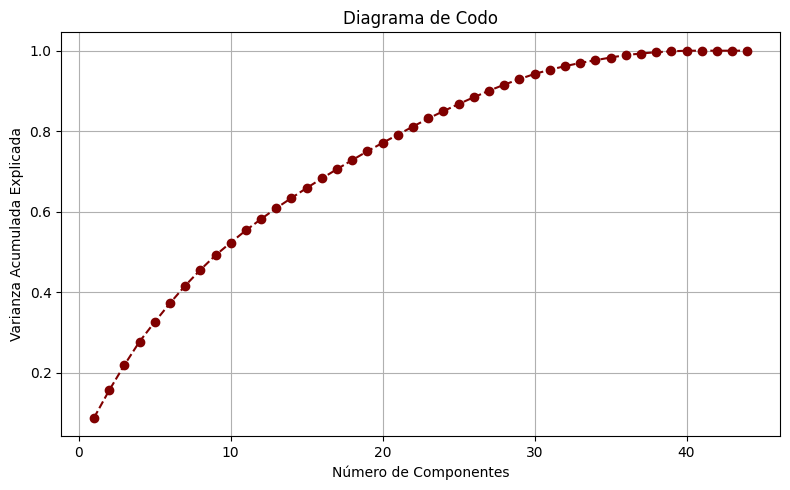

In [108]:
pca_02.plot_elbow()

In [109]:
print("Componentes:", pca_02.r_pca()[0].shape[1])

Componentes: 27


### Vecinos Cercanos

In [110]:
data2 = pca_02.r_pca()[0]

In [111]:
kmeans2 = rKMeans(dataframe=data2, cols=None, max_clusters=10, random_state=42)

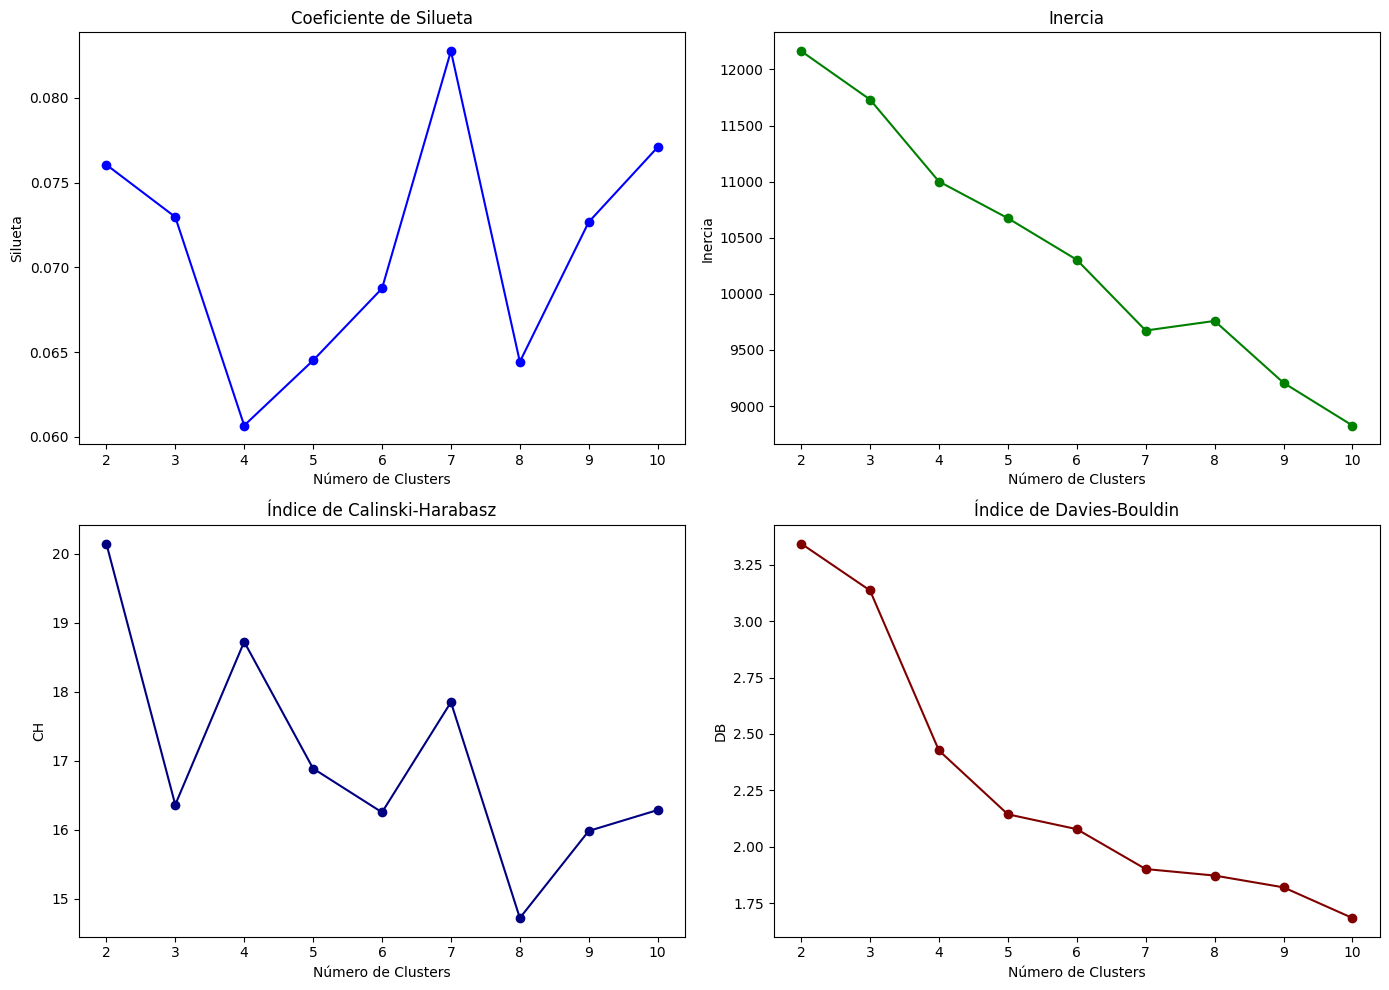

,Clusters,Silueta,Inercia,Calinski-Harabasz,Davies-Bouldin
0,2,0.076056,12163.457536,20.146084,3.344483
1,3,0.072973,11731.376311,16.360057,3.136407
2,4,0.060673,11000.874123,18.722308,2.426509
3,5,0.064513,10673.899417,16.885236,2.143457
4,6,0.068757,10303.595077,16.250188,2.077648
5,7,0.082760,9672.866610,17.846536,1.900678
6,8,0.064431,9758.211924,14.718391,1.871741
7,9,0.072679,9206.747342,15.980521,1.819460
8,10,0.077089,8826.401791,16.283282,1.683486


In [112]:
kmeans2.optimal_clusters()

### Interpretación de Gráficos

El análisis de métricas de validación interna sugiere que la elección del número de clusters más apropiado se encuentra entre **2 y 7**. El valor de silueta alcanza su máximo en 7 clusters, lo que indica una buena separación relativa entre grupos. La inercia también muestra un punto de inflexión en torno a 6–7 clusters, mientras que el índice de Davies-Bouldin disminuye de forma consistente hasta estabilizarse a partir de ese rango. Por otro lado, el índice de Calinski-Harabasz señala que con **2 clusters** se logra la mejor compacidad, aunque con **7 clusters** se conserva una definición aceptable. En conjunto, se puede concluir que la solución de **7 clusters** es adecuada si se busca una segmentación más granular, mientras que **2 clusters** representaría una división más general.

In [113]:
pca = PCA(n_components=0.90, random_state=42) # conserva 90% de varianza
X_pca = pca.fit_transform(X_scaled)

# Dataset reducido (ya con PCA o escalado)
X_data = X_pca

best_score = -1.0
best_state = None
best_model = None
scores = []

for rs in range(100):
    km = KMeans(n_clusters=7, random_state=rs, n_init="auto")  
    labels = km.fit_predict(X_data)
    score = silhouette_score(X_data, labels)
    scores.append((rs, score))
    if score > best_score:
        best_score = score
        best_state = rs
        best_model = km

print(f"✅ Mejor silueta: {best_score:.4f} con random_state = {best_state}")

✅ Mejor silueta: 0.0931 con random_state = 83


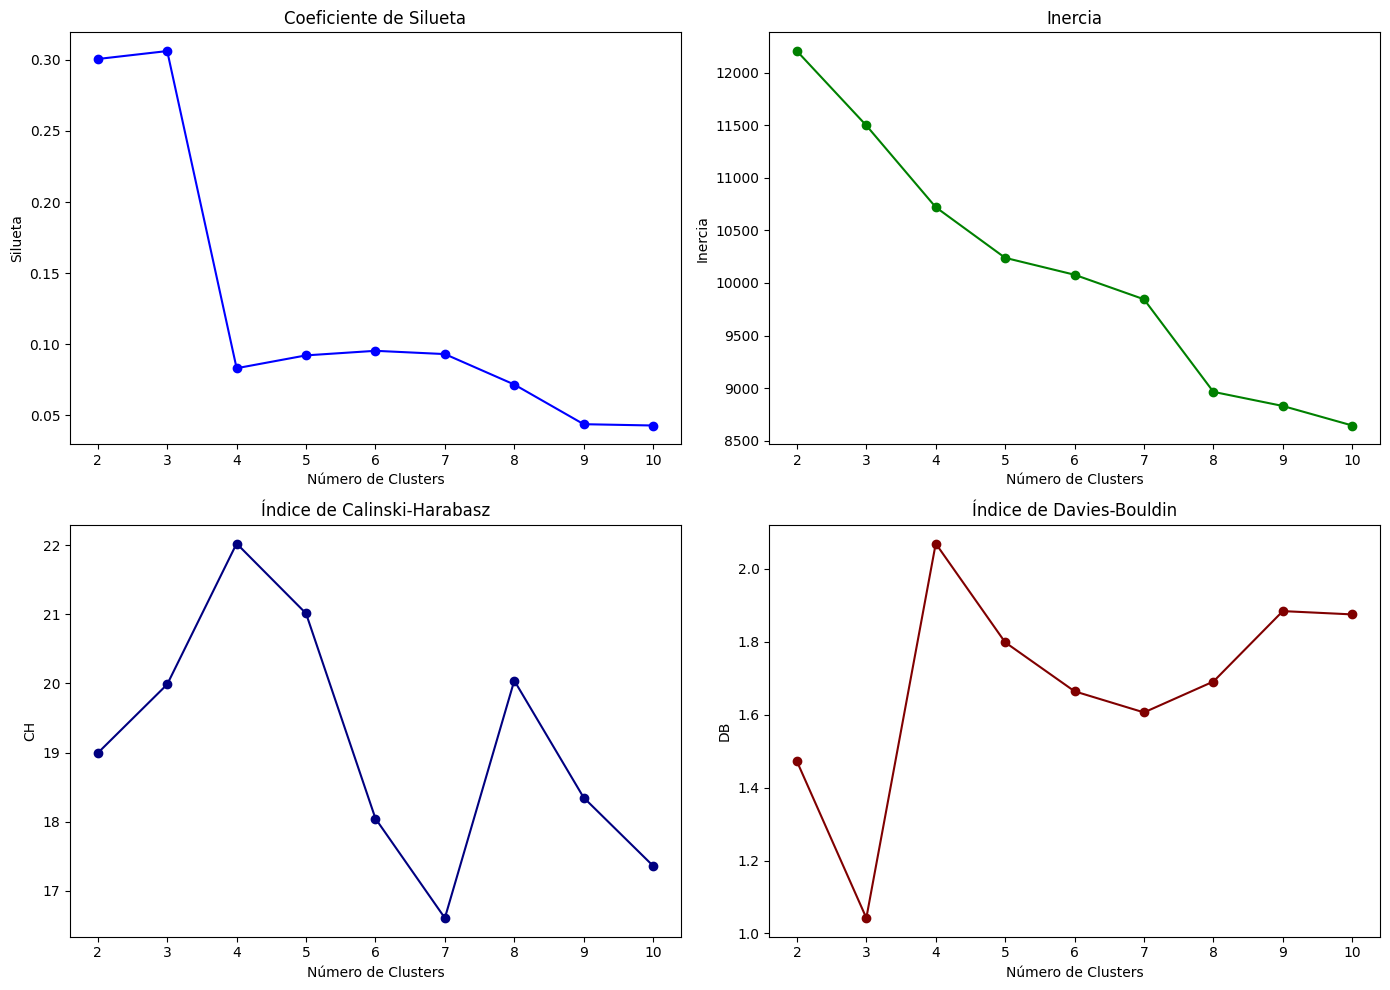

,Clusters,Silueta,Inercia,Calinski-Harabasz,Davies-Bouldin
0,2,0.300551,12204.325005,18.993675,1.471946
1,3,0.306131,11496.943354,19.986782,1.042381
2,4,0.083179,10720.106612,22.023799,2.069108
3,5,0.092202,10238.846765,21.012551,1.798316
4,6,0.095416,10078.095281,18.045805,1.663953
5,7,0.093113,9844.743704,16.606733,1.606044
6,8,0.071713,8964.869503,20.041072,1.690739
7,9,0.043828,8830.742622,18.348152,1.883892
8,10,0.042913,8645.125376,17.360952,1.874833


In [114]:
kmeans2.optimal_clusters(random_state=83)

Probando con la mejor semilla para 7 clusters vemos mejor silueta para el grupo de 2 clusters.

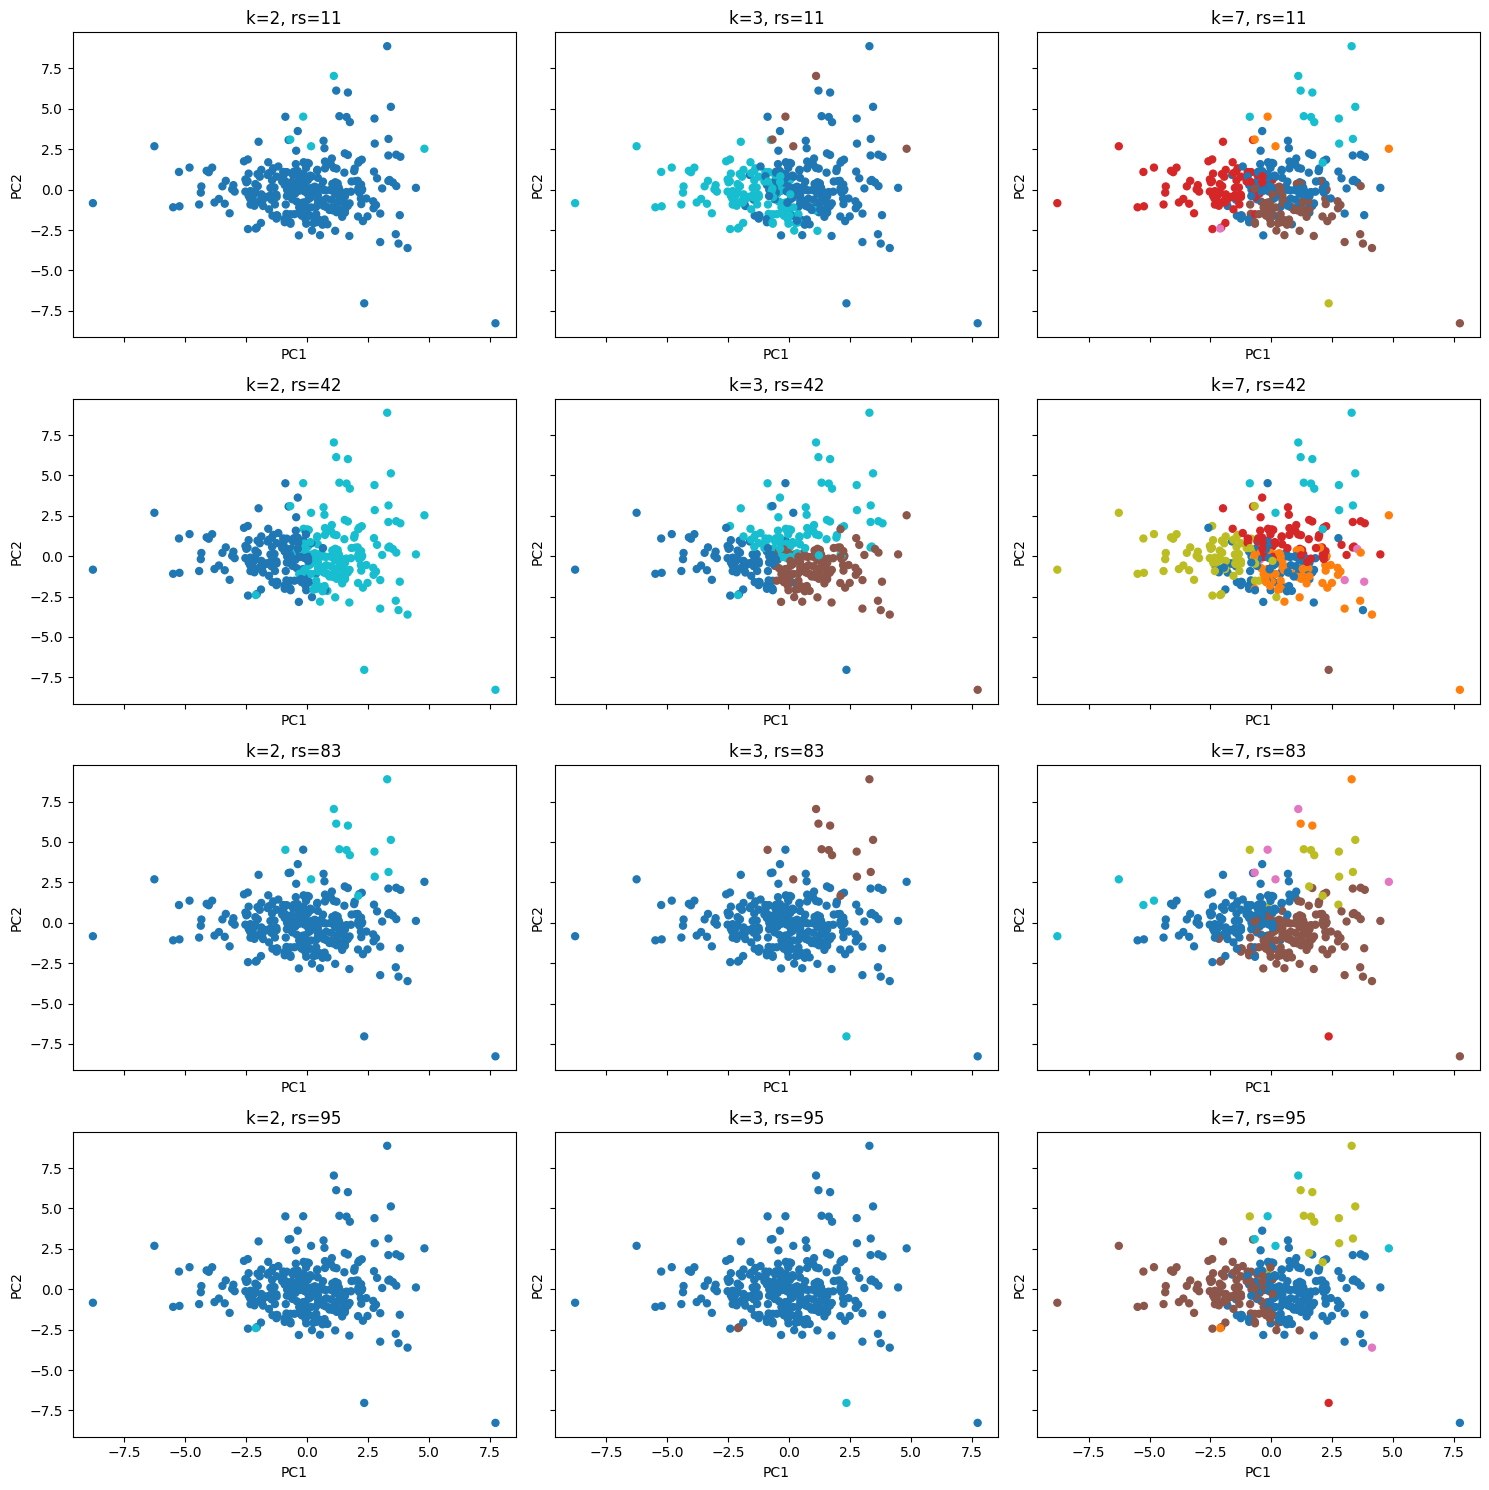

In [115]:
n_clusters_list = [2, 3, 7]          # columnas
random_states = [11, 42, 83, 95]         # filas

fig, axes = plt.subplots(len(random_states), len(n_clusters_list),
                         figsize=(15, 15), sharex=True, sharey=True)

for i, rs in enumerate(random_states):
    for j, k in enumerate(n_clusters_list):
        ax = axes[i, j]
        kmeans = KMeans(n_clusters=k, random_state=rs, n_init="auto")
        labels = kmeans.fit_predict(X_pca)
        
        scatter = ax.scatter(X_pca[:,0], X_pca[:,1],
                             c=labels, cmap="tab10", s=25)
        ax.set_title(f"k={k}, rs={rs}")
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()

* Aunque en el corrido de simulaciones para encontrar la mejor semilla para 7 clusters (semilla 83) vemos en el gráfico 2D que los puntos se sobreponen y es más, observamos mejor silueta para el grupo de 2 clusters.
* A pesar de probar configuraciones con 2, 3 y 7 clusters, los resultados muestran un alto solapamiento entre grupos. La visualización en componentes principales evidencia que los clusters no presentan fronteras claras, lo cual coincide con los bajos valores de silueta.
* No hay una buena segmentación de clusters y tiene sentido porque hablamos de un sólo artista por lo que esperamos un sólo genero musical, tonalidades similares en las canciones, bailabilidad e incluso letras similares (misma longitud, misma cantidad de versos, misma cantidad de vocales o sílabas usadas, entre otras métricas).
* Con el fin de ver los resultados con dos clusters eligiremos el de 2 con semilla 42 para ver las características de cada cluster aunque por el punto anterior consideramos también que nos referimos en realidad a un sólo cluster (un sólo artista o geńero musical en el dataset).

,count,proportion
cluster,,
1,169,51.8%
0,157,48.2%


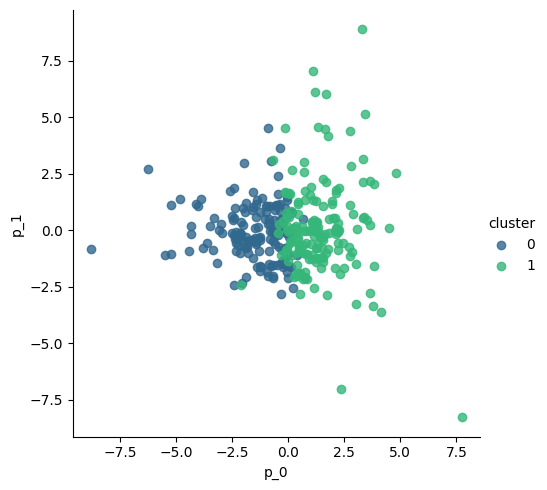

In [116]:
kmeans2.fit(n_clusters=2, random_state=42)
kmeans2.plot(data2)
df_song['cluster'] = kmeans2.get_df()['cluster']

display(pd.concat([df_song['cluster'].value_counts(), df_song['cluster'].value_counts(normalize=True).apply(lambda x: '{:.1%}'.format(x))], axis=1))

In [117]:
perfil2 = Perfil(df_song, var_cat, num_cols)

In [118]:
aux2 = perfil2.kw_test().sort_values(by='p-value', ascending=False).reset_index(drop=True)

var_sig2 = aux2.loc[aux2['p-value'] < 0.05, "Variable"].tolist()
var_nosig2 = aux2.loc[aux2['p-value'] >= 0.05, "Variable"].tolist()

print('\nVariables no significativas\n')
display(aux2.query(f"Variable == {var_nosig2}"))

print('\nVariables significativas\n')
display(aux2.query(f"Variable == {var_sig2}"))


Variables no significativas



,Variable,p-value
0,elem_prop_Break,0.95493
1,danceability,0.68390
2,duration_ms,0.41058
3,elem_prop_Interlude,0.35651
4,n_unique,0.34043
5,elem_prop_Bridge 2,0.33512
6,elem_prop_Verse 5,0.33512
7,elem_prop_Verse,0.33512
8,elem_prop_Bridge 1,0.33512
9,elem_prop_Chorus 3,0.33512



Variables significativas



,Variable,p-value
24,elem_prop_Chorus 1,0.03012
25,elem_prop_Verse 4,0.03012
26,elem_prop_Chorus 2,0.00586
27,valence,0.00363
28,elem_prop_Pre-Chorus 1,0.00334
29,elem_prop_Post-Chorus,0.00180
30,elem_prop_Verse 3,0.00120
31,elem_prop_Pre-Chorus 2,0.00069
32,elem_prop_Intro,0.00032
33,stop_ratio,0.00001


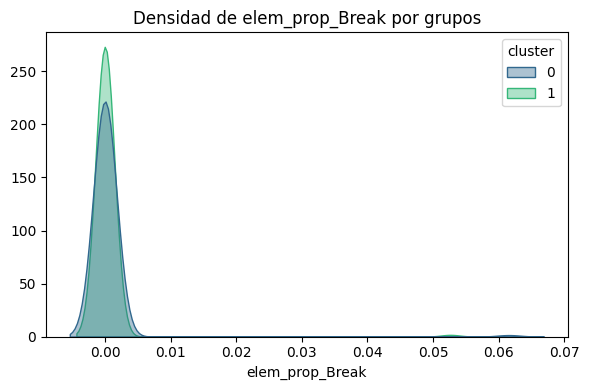

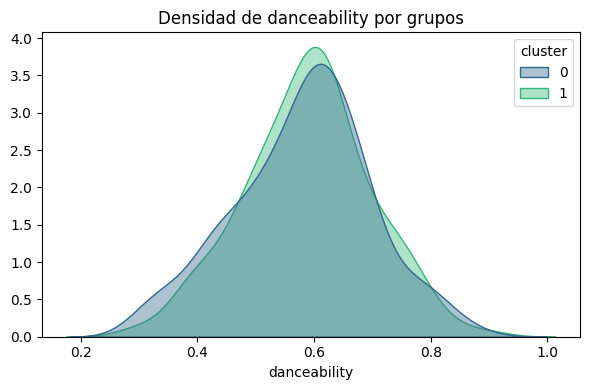

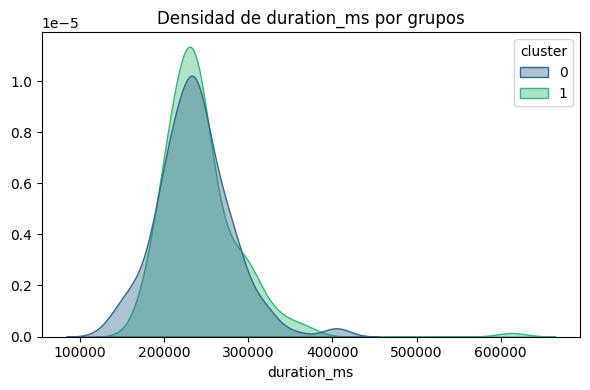

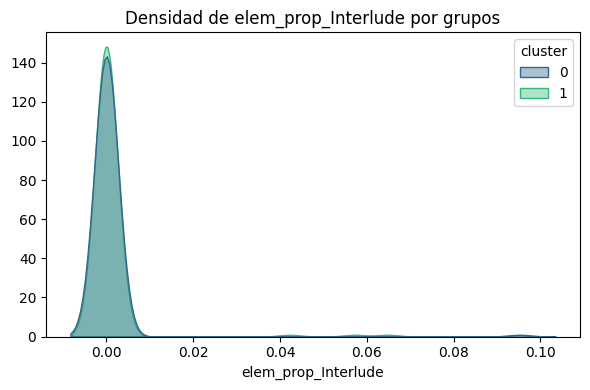

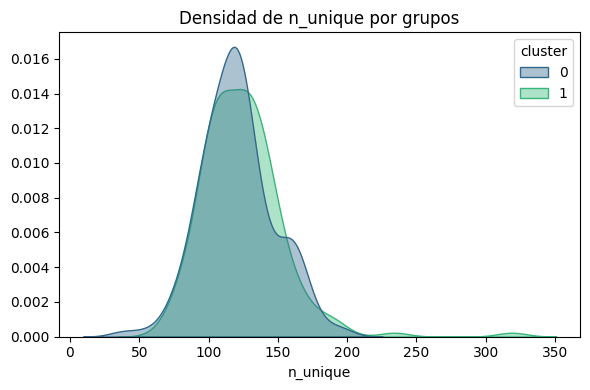

/tmp/ipykernel_3403/2607923038.py:15: UserWarning:

Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.



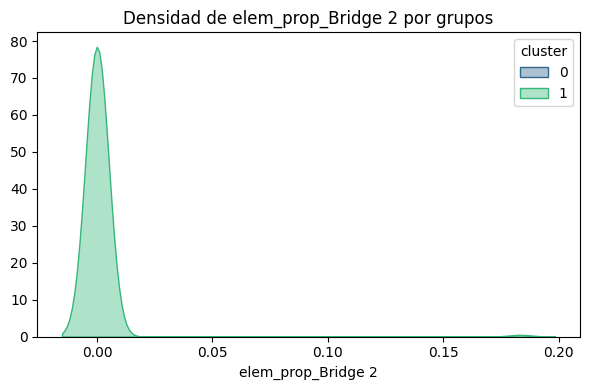

/tmp/ipykernel_3403/2607923038.py:15: UserWarning:

Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.



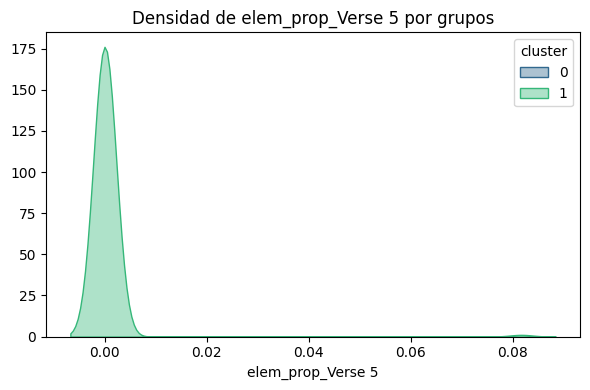

/tmp/ipykernel_3403/2607923038.py:15: UserWarning:

Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.



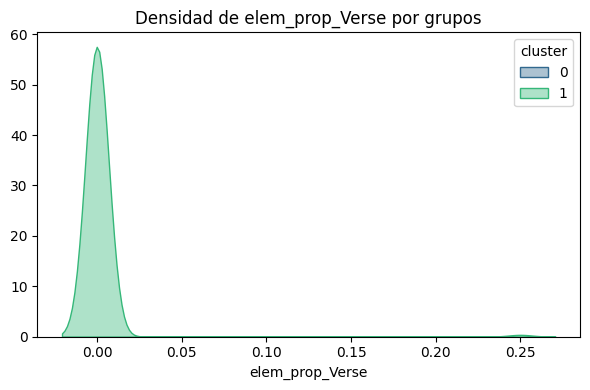

/tmp/ipykernel_3403/2607923038.py:15: UserWarning:

Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.



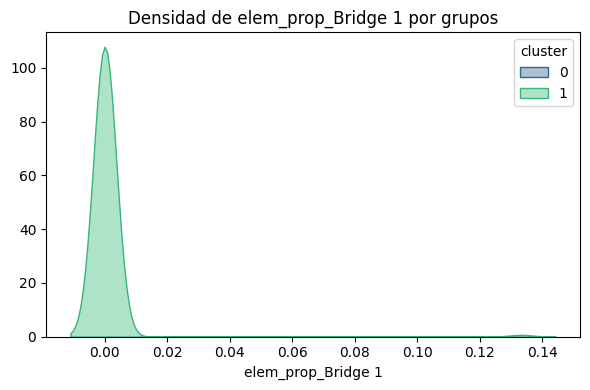

/tmp/ipykernel_3403/2607923038.py:15: UserWarning:

Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.



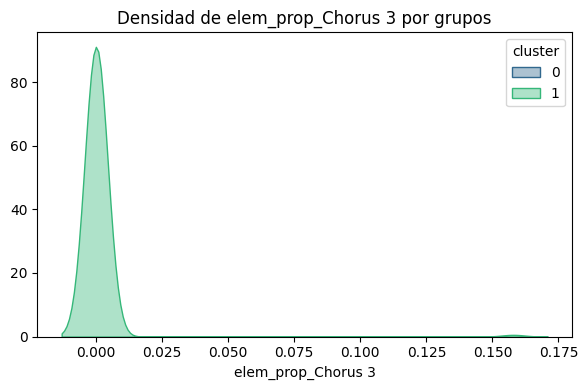

/tmp/ipykernel_3403/2607923038.py:15: UserWarning:

Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.



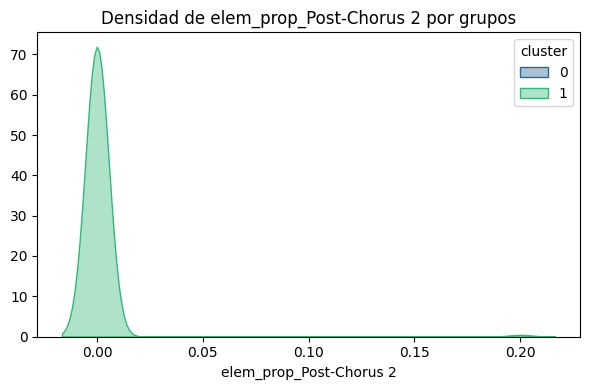

/tmp/ipykernel_3403/2607923038.py:15: UserWarning:

Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.



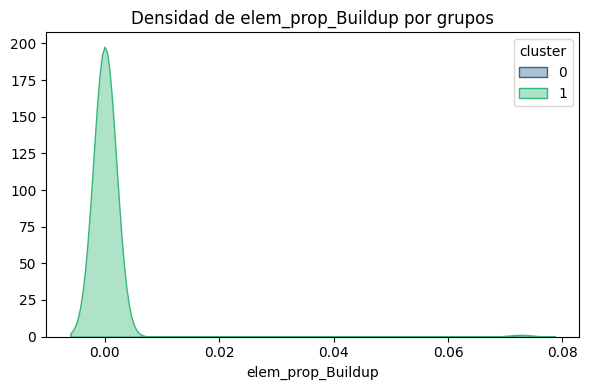

/tmp/ipykernel_3403/2607923038.py:15: UserWarning:

Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.



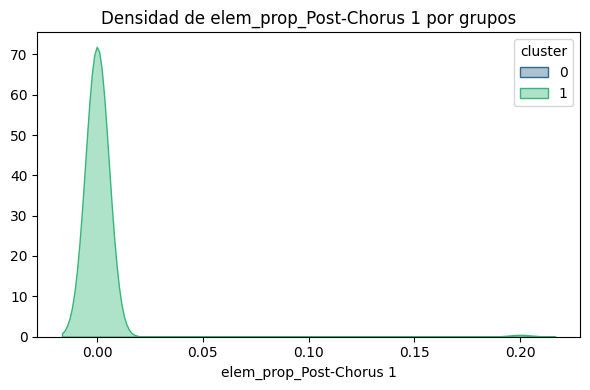

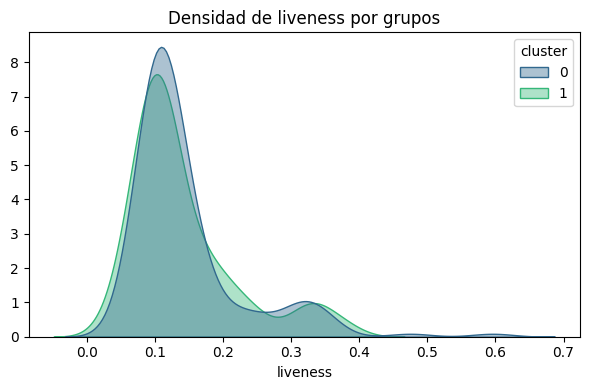

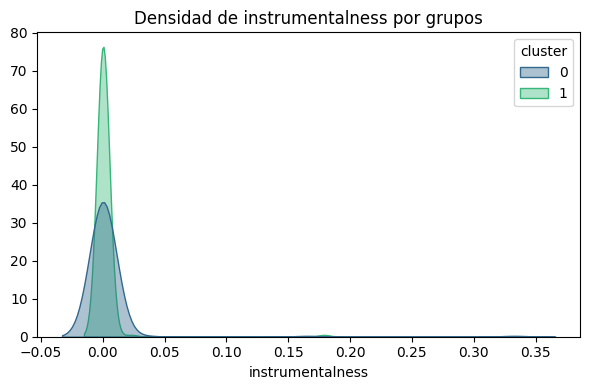

/tmp/ipykernel_3403/2607923038.py:15: UserWarning:

Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.



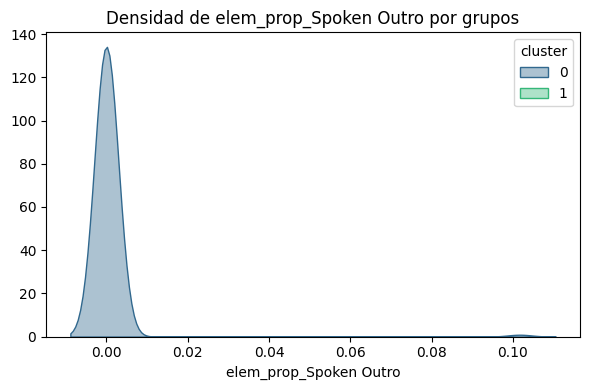

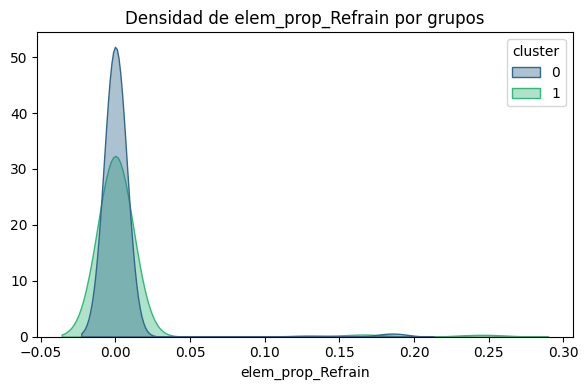

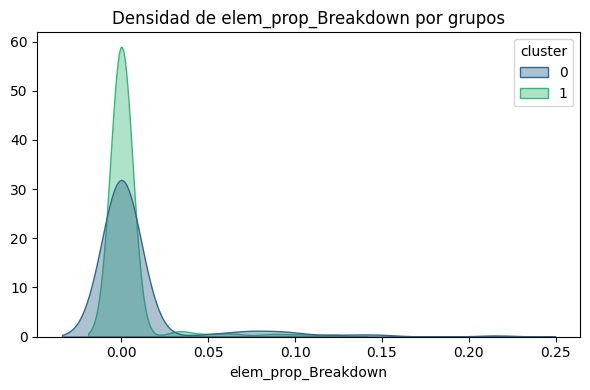

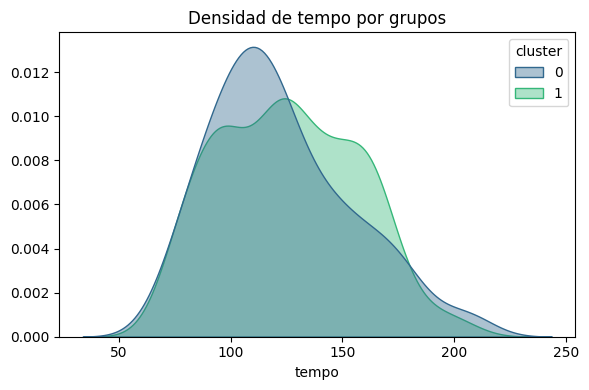

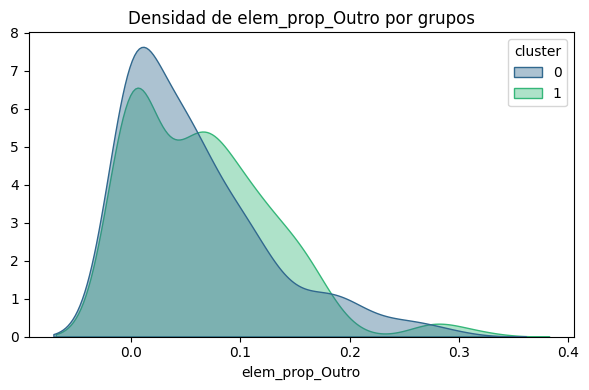

/tmp/ipykernel_3403/2607923038.py:15: UserWarning:

Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.



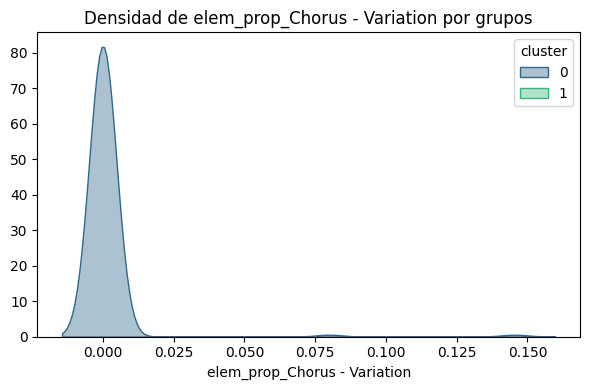

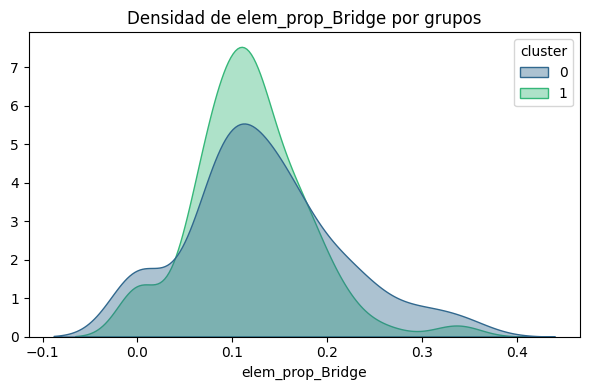

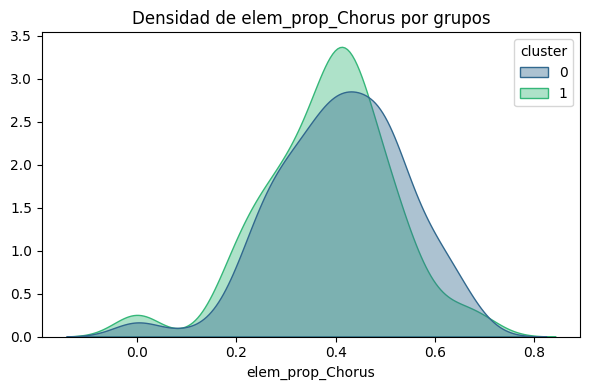

/tmp/ipykernel_3403/2607923038.py:15: UserWarning:

Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.



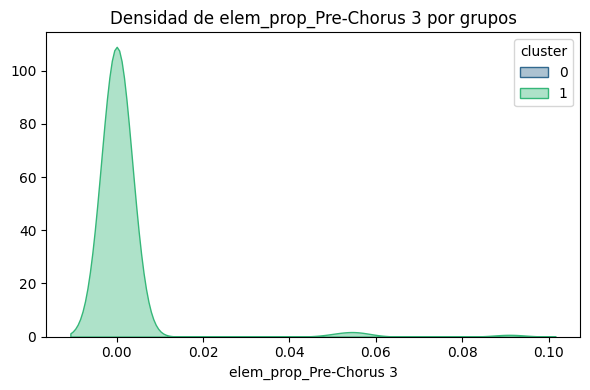

In [119]:
# Distribución de variables no significativas
perfil2.plot_dist(var_nosig2)

/tmp/ipykernel_3403/2607923038.py:15: UserWarning:

Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.



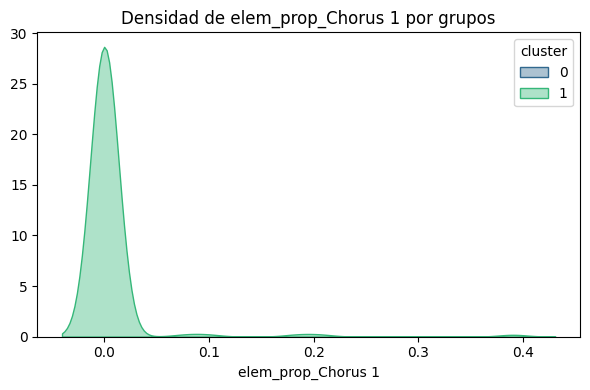

/tmp/ipykernel_3403/2607923038.py:15: UserWarning:

Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.



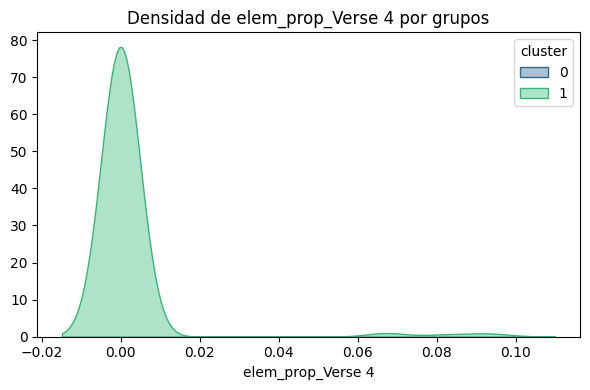

/tmp/ipykernel_3403/2607923038.py:15: UserWarning:

Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.



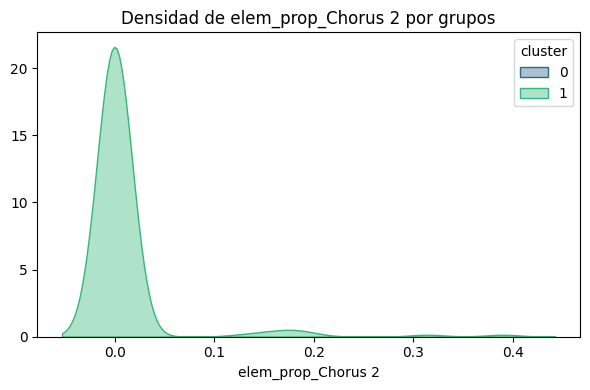

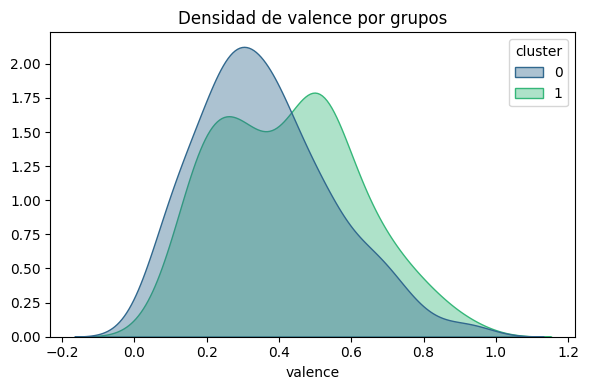

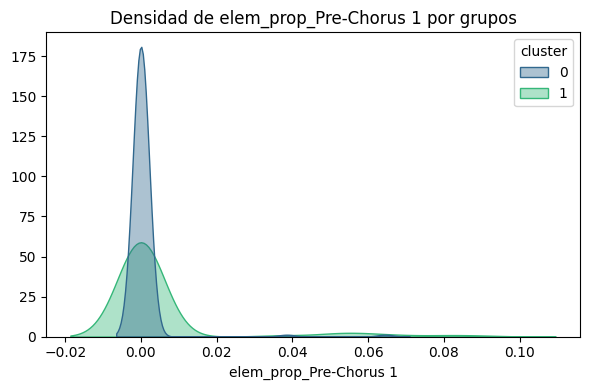

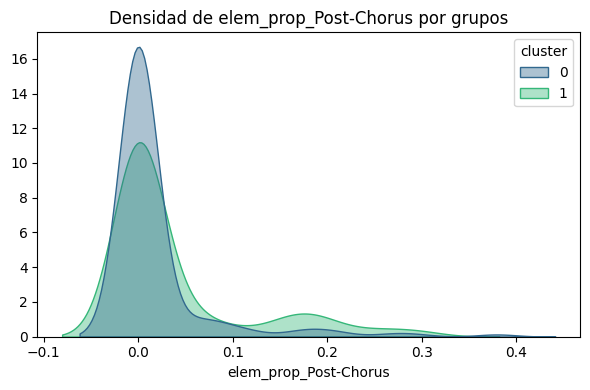

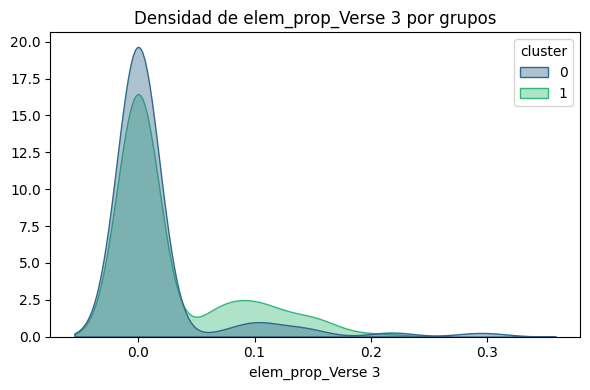

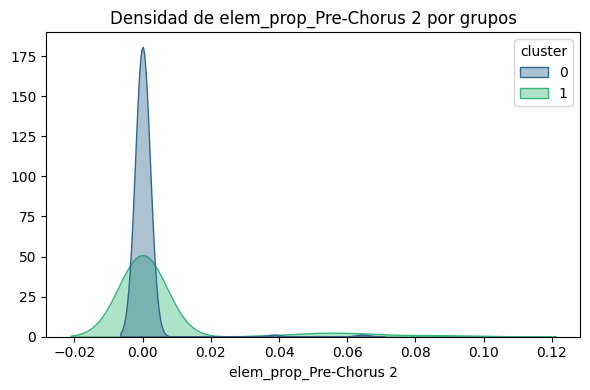

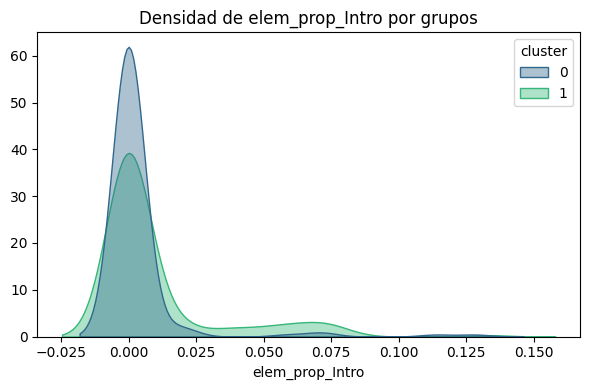

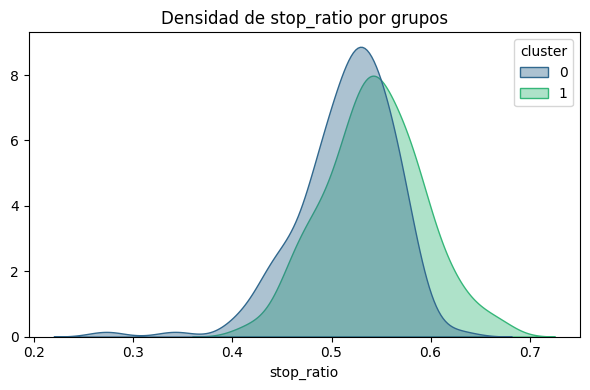

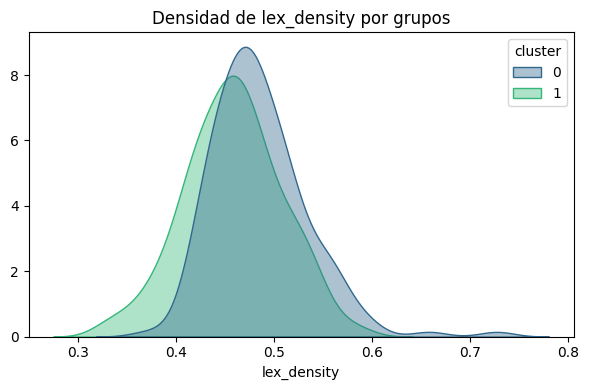

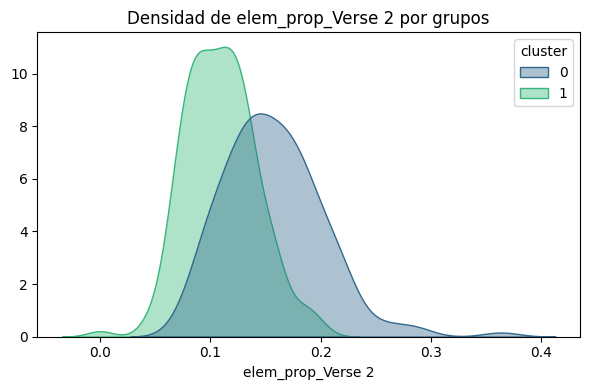

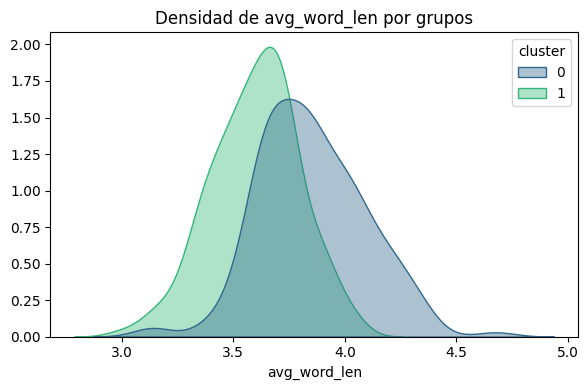

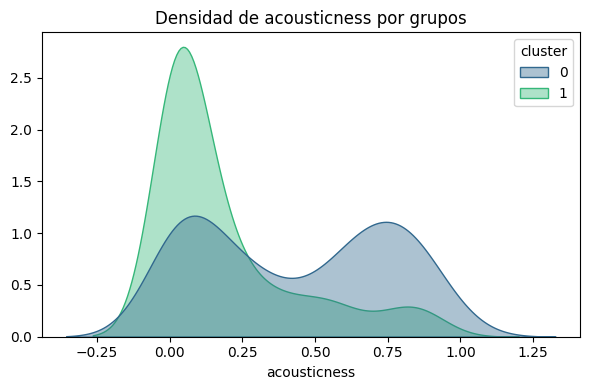

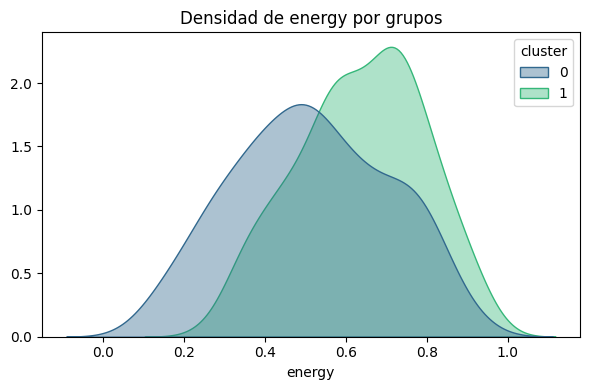

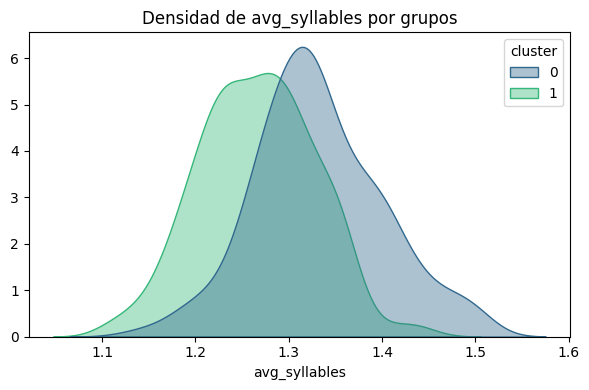

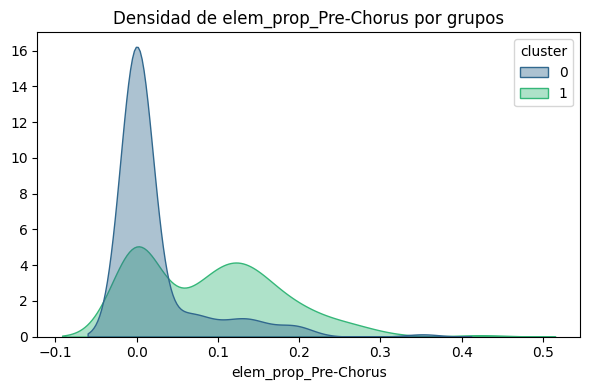

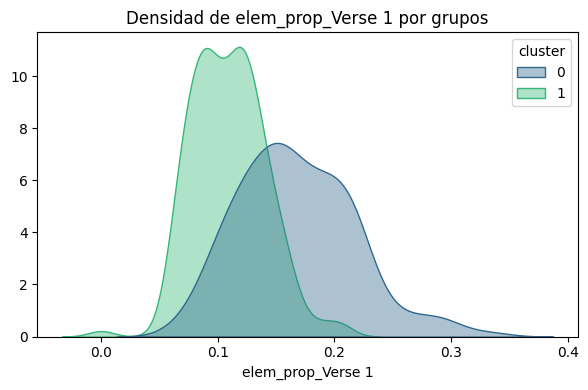

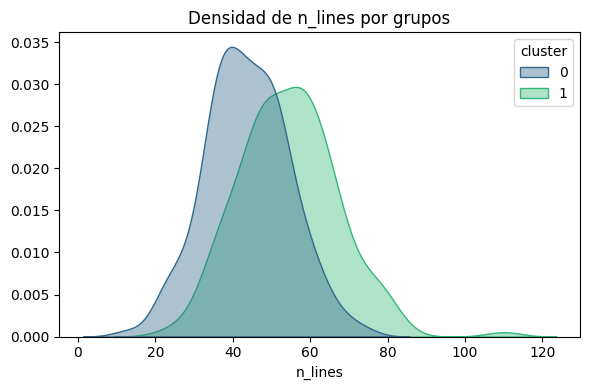

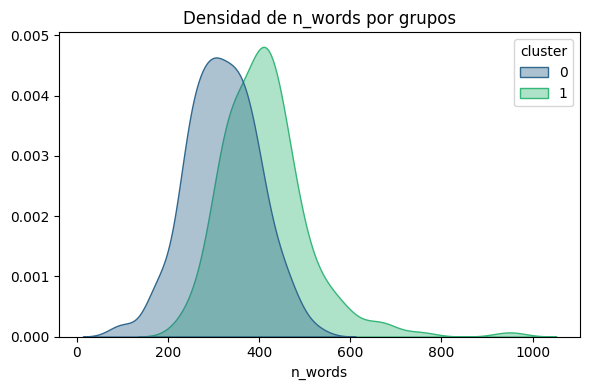

In [120]:
# Distribución de variables significativas
perfil2.plot_dist(var_sig2)

In [121]:
# Pipelines
num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# ColumnTransformer
pre = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

In [122]:
values = pre.fit_transform(df_song)
imputed_df = pd.DataFrame(data=values, columns=pre.get_feature_names_out())

In [123]:
imputed_df['cluster'] = df_song['cluster']

In [124]:
clase2 = playlist(
    df=imputed_df, 
    selection=['danceability','duration_min','liveness','tempo','n_words','n_lines','elem_prop_Pre-Chorus 1','acousticness','energy','valence','elem_prop_Verse 1'],
    sig_var=var_sig2,
    other_var=['danceability','duration_ms','liveness','tempo']
    #group_var=['cluster']
)

In [125]:
clase2.resumen(agg='mean')

,cluster,count,count,valence,elem_prop_Bridge 2,elem_prop_Verse,elem_prop_Bridge 1,elem_prop_Chorus 3,elem_prop_Interlude,lex_density,...,elem_prop_Outro,acousticness,elem_prop_Chorus,duration_ms,elem_prop_Buildup,elem_prop_Pre-Chorus 2,danceability,n_lines,elem_prop_Post-Chorus 2,elem_prop_Chorus - Variation
0,0,157,120.579618,0.362562,0.000000,0.000000,0.000000,0.000000,0.000607,0.484839,...,0.058111,0.42572,0.410044,236252.089172,0.00000,0.000656,0.580478,43.713376,0.000000,0.001436
1,1,169,124.284024,0.424459,0.001085,0.001479,0.000789,0.000934,0.000972,0.457677,...,0.065406,0.18429,0.383500,243218.349112,0.00043,0.006299,0.588734,54.461538,0.001183,0.000000


In [126]:
clase2.select(0)

,danceability,duration_min,liveness,tempo,n_words,n_lines,elem_prop_Pre-Chorus 1,acousticness,energy,valence,elem_prop_Verse 1
0,0.789,3 min and 32 s,0.3020,116.992,348.0,43.0,0.000000,0.03480,0.634,0.658,0.113636
2,0.588,3 min and 51 s,0.1180,94.933,383.0,47.0,0.000000,0.00245,0.791,0.487,0.208333
12,0.815,4 min and 31 s,0.1000,103.970,340.0,51.0,0.038462,0.23200,0.377,0.211,0.096154
14,0.474,4 min and 27 s,0.0903,170.109,409.0,52.0,0.000000,0.70700,0.480,0.319,0.207547
16,0.760,3 min and 32 s,0.3250,116.989,348.0,39.0,0.000000,0.00661,0.602,0.685,0.125000
...,...,...,...,...,...,...,...,...,...,...,...
306,0.317,4 min and 49 s,0.0867,93.933,185.0,23.0,0.000000,0.72700,0.254,0.103,0.208333
308,0.644,3 min and 54 s,0.0909,150.072,287.0,32.0,0.000000,0.91600,0.284,0.328,0.212121
309,0.676,3 min and 40 s,0.1350,118.840,245.0,37.0,0.000000,0.96400,0.178,0.404,0.210526
310,0.313,3 min and 31 s,0.0948,179.947,235.0,27.0,0.000000,0.84200,0.258,0.268,0.107143


In [127]:
clase2.select(0).describe()

,danceability,liveness,tempo,n_words,n_lines,elem_prop_Pre-Chorus 1,acousticness,energy,valence,elem_prop_Verse 1
count,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000
mean,0.580478,0.144713,122.411070,319.949045,43.713376,0.000656,0.425720,0.514529,0.362562,0.167394
std,0.114795,0.082415,31.295243,77.654874,10.714267,0.005978,0.323325,0.188625,0.183718,0.049691
min,0.310000,0.059300,68.534000,98.000000,13.000000,0.000000,0.000191,0.118000,0.038400,0.067797
25%,0.511000,0.101000,99.981000,264.000000,36.000000,0.000000,0.103000,0.379000,0.232000,0.129032
50%,0.596000,0.114000,118.043000,315.000000,44.000000,0.000000,0.420000,0.509000,0.347000,0.160000
75%,0.655000,0.148000,142.377000,375.000000,51.000000,0.000000,0.727000,0.646000,0.472000,0.200000
max,0.872000,0.596000,208.918000,527.000000,74.000000,0.064516,0.971000,0.902000,0.928000,0.333333


In [128]:
clase2.select(1)

,danceability,duration_min,liveness,tempo,n_words,n_lines,elem_prop_Pre-Chorus 1,acousticness,energy,valence,elem_prop_Verse 1
1,0.760,3 min and 51 s,0.0913,95.997,509.0,83.0,0.0,0.103000,0.703,0.5700,0.095238
3,0.553,3 min and 55 s,0.3410,92.008,662.0,69.0,0.0,0.000743,0.841,0.3380,0.128571
4,0.605,3 min and 13 s,0.1010,96.970,467.0,66.0,0.0,0.002010,0.725,0.5390,0.119403
5,0.647,3 min and 39 s,0.3340,160.078,617.0,76.0,0.0,0.064700,0.800,0.9420,0.103896
6,0.653,3 min and 27 s,0.1020,118.035,590.0,76.0,0.0,0.015800,0.893,0.5130,0.064935
...,...,...,...,...,...,...,...,...,...,...,...
320,0.675,3 min and 34 s,0.0391,110.010,478.0,58.0,0.0,0.008820,0.703,0.3140,0.067797
321,0.624,3 min and 31 s,0.1380,160.024,433.0,65.0,0.0,0.060400,0.691,0.2840,0.121212
322,0.719,3 min and 50 s,0.1690,120.085,496.0,66.0,0.0,0.032900,0.469,0.0851,0.059701
323,0.567,3 min and 27 s,0.3820,163.960,418.0,51.0,0.0,0.015600,0.789,0.4380,0.115385


In [129]:
clase2.select(1).describe()

,danceability,liveness,tempo,n_words,n_lines,elem_prop_Pre-Chorus 1,acousticness,energy,valence,elem_prop_Verse 1
count,169.000000,169.000000,169.000000,169.000000,169.000000,169.000000,169.000000,169.000000,169.000000,169.000000
mean,0.588734,0.139646,125.698497,412.769231,54.461538,0.005017,0.184290,0.634408,0.424459,0.109360
std,0.106570,0.077114,30.290086,95.041031,12.635457,0.017328,0.241203,0.152922,0.192463,0.031239
min,0.292000,0.035700,73.942000,237.000000,23.000000,0.000000,0.000197,0.270000,0.049900,0.000000
25%,0.521000,0.092000,99.979000,345.000000,46.000000,0.000000,0.015800,0.535000,0.275000,0.085106
50%,0.596000,0.114000,123.054000,404.000000,55.000000,0.000000,0.073900,0.634000,0.417000,0.107143
75%,0.647000,0.167000,148.035000,454.000000,62.000000,0.000000,0.225000,0.747000,0.545000,0.129032
max,0.897000,0.382000,200.391000,950.000000,110.000000,0.090909,0.937000,0.950000,0.942000,0.205128


## Conclusión

La principal diferencia entre estos clusters es la acústica de las canciones, el grupo del cluster 1 se compone de canciones con mayor probabilidad o confianza de que sean acústicas a diferencia del cluster 2.

Otras variables que podríamos considerar para un análisis más complejo son:
* Cantidad de vistas
* Intervalos de tiempo más escuchados en plataformas como YouTube y Spotify
* Edad de público oyente

Con esta información sería posible identificar cuáles canciones generan mayor interés en el público y, en particular, cuáles fragmentos de las canciones capturan más su atención. Al disponer también de las letras, podríamos analizar qué estilos rítmicos y temáticas líricas resultan más atractivos, lo que serviría como base para orientar la composición de futuras canciones hacia esos patrones de preferencia.

En seguimiento con la respuesta anterior, podríamos definir como variable objetivo las canciones más gustadas por el público, la cantidad de vistas de cada canción debería guardar una relación con sus características o métricas musicales, como el ritmo, la letra y los gustos del público, lo cual se refleja directamente en el número de reproducciones.